---

In [9]:
import tensorflow as tf

tfrecord_files = [
    # "/pdo/users/pablomer/mnt/tess/astronet/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-val/00000-of-00005" #
    # '/pdo/astronet-data/data/tfrecords/oct2025_original/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-val/00000-of-00050'
    '/pdo/astronet-data/data/tfrecords/oct2025_cadencebin/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-val/00000-of-00050'
    # '/pdo/astronet-data/data/tfrecords/sector-87/00000-of-00025'
]

# Dictionary to hold feature data
example_data = {}

raw_dataset = tf.data.TFRecordDataset(tfrecord_files)


import random

# Count total records (can be slow for large files)
total = sum(1 for _ in raw_dataset)
# random_index = random.randint(0, total - 1)
random_index=1

for raw_record in raw_dataset.skip(random_index).take(1):
    example = tf.train.Example()
    example.ParseFromString(raw_record.numpy())

    for key, feature in example.features.feature.items():
        if feature.HasField("float_list"):
            example_data[key] = list(feature.float_list.value)
        elif feature.HasField("int64_list"):
            example_data[key] = list(feature.int64_list.value)
        elif feature.HasField("bytes_list"):
            example_data[key] = [v.decode("utf-8") for v in feature.bytes_list.value]
        else:
            example_data[key] = None  # unknown type


2025-10-23 15:31:41.895200: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1]
	 [[{{node Placeholder/_0}}]]
2025-10-23 15:31:42.163470: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1]
	 [[{{node Placeholder/_0}}]]
2025-10-23 15:31:42.163846: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1]
	 [[{{n

In [10]:
random_index

1

In [11]:
example_data.keys()

dict_keys(['local_view', 'local_aperture_l', 'local_scale_present', 'secondary_std', 'local_scale_present_0.3', 'local_std', 'global_view_double_period', 'star_mass_present', 'local_std_even', 'global_view_half_period_0.3', 'local_view_half_period_0.3', 'local_mask', 'secondary_view_0.3', 'global_view_double_period_mask_0.3', 'global_view_double_period_mask', 'local_aperture_m_0.3', 'global_view_0.3', 'astro_id', 'local_std_odd', 'local_view_odd', 'global_view_double_period_std_0.3', 'local_std_odd_0.3', 'local_aperture_l_5.0', 'global_view_half_period', 'star_rad', 'global_view_double_period_mask_5.0', 'secondary_scale_5.0', 'global_mask_5.0', 'local_mask_odd', 'global_view_half_period_std', 'local_mask_5.0', 'local_view_half_period_5.0', 'star_rad_est', 'local_view_half_period_std_5.0', 'global_view_half_period_5.0', 'secondary_view_5.0', 'local_view_odd_5.0', 'local_std_even_5.0', 'local_view_even_5.0', 'local_view_even', 'global_transit_mask_5.0', 'global_view_half_period_mask_0.3'

In [4]:
print(example_data['astro_id'])

[4124]


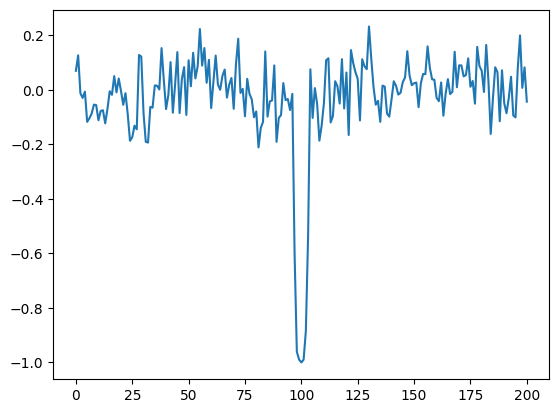

In [12]:
import numpy as np
import matplotlib.pyplot as plt
x=np.array(example_data['global_view'])
x.shape

x_one=x[:201]

plt.plot(x_one)
plt.show()

Feature 'disp_p' not found.
Feature 'disp_b' not found.
Feature 'disp_e' not found.
Feature 'disp_n' not found.
Feature 'disp_t' not found.
Feature 'disp_u' not found.
Feature 'disp_j' not found.
Scalar Features:
  astro_id: 4124


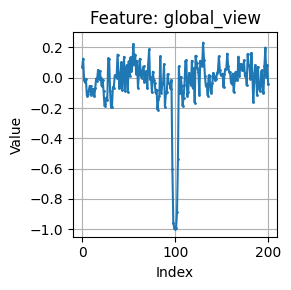

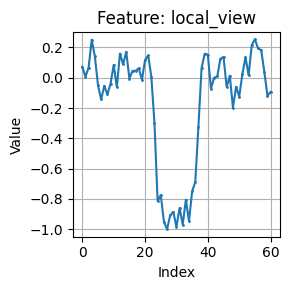

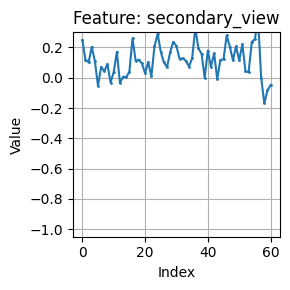

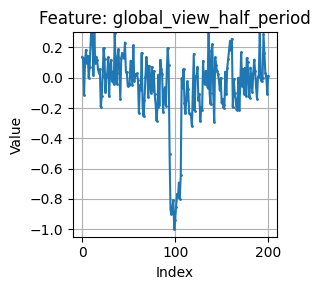

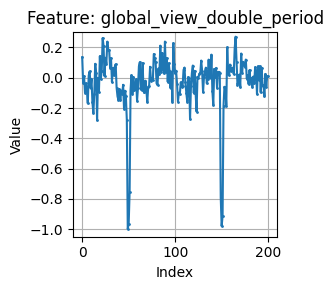

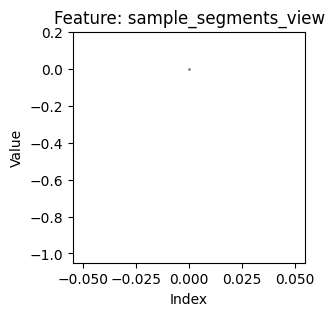

In [13]:
import matplotlib.pyplot as plt

def inspect_features(feature_names, max_points=None):
    """
    For each feature in feature_names:
      - If the feature is scalar (only one value), store it in a dictionary.
      - If the feature has more than one value, prepare it for plotting.

    Args:
      feature_names (list of str): List of feature names to inspect.
      max_points (int, optional): If provided, limits the number of data points plotted.
    """
    scalars = {}
    sequences = []

    for name in feature_names:
        if name not in example_data:
            print(f"Feature '{name}' not found.")
            continue

        data = example_data[name]
        # Ensure data is in list format
        if not isinstance(data, list):
            data = [data]

        if len(data) == 1:
            scalars[name] = data[0]
        else:
            sequences.append((name, data))

    # Print all scalar features together
    if scalars:
        print("Scalar Features:")
        for key, val in scalars.items():
            print(f"  {key}: {val}")
    else:
        print("No scalar features found.")

    # Now, plot each non-scalar feature
    for name, data in sequences:
        # check if 'segments' is in the name
        if 'segments' not in name:

            plot_data = data[:max_points] if max_points is not None else data
            plt.figure(figsize=(3, 3))
            plt.plot(plot_data, marker='o', markersize=1)
            plt.title(f"Feature: {name}")
            plt.xlabel("Index")
            plt.ylabel("Value")
            plt.ylim(-1.05,0.3)
            plt.grid(True)
            plt.tight_layout()
            plt.show()
        else:
            #Plot the segments (the data is 14x61)
            plt.figure(figsize=(3, 3))
            for i in range(14):
                plt.plot(data[i], marker='o', markersize=1)
            plt.title(f"Feature: {name}")
            plt.xlabel("Index")
            plt.ylabel("Value")
            plt.ylim(-1.05,0.2)




# Example usage:
# plot_feature("global_view")
# plot_feature("local_view")
# plot_feature("local_view")
# You can also call: plot_feature("local_view_half_period_0.3")

# features_list=['local_view', 'local_aperture_l', 'local_scale_present', 'secondary_std', 'local_scale_present_0.3', 'local_std', 'global_view_double_period', 'star_mass_present', 'local_std_even', 'global_view_half_period_0.3', 'local_view_half_period_0.3', 'local_mask', 'secondary_view_0.3', 'global_view_double_period_mask_0.3', 'global_view_double_period_mask', 'local_aperture_m_0.3', 'global_view_0.3', 'astro_id', 'local_std_odd', 'local_view_odd', 'global_view_double_period_std_0.3', 'disp_p', 'local_std_odd_0.3', 'global_view_half_period', 'star_rad', 'disp_b', 'disp_e', 'global_view_double_period_mask_5.0', 'secondary_scale_5.0', 'global_mask_5.0', 'local_aperture_l_5.0', 'local_mask_odd', 'global_view_half_period_std', 'local_mask_5.0', 'disp_u', 'star_rad_est', 'local_view_half_period_5.0', 'local_view_half_period_std_5.0', 'global_view_half_period_5.0', 'secondary_view_5.0', 'local_view_odd_5.0', 'local_std_even_5.0', 'local_view_even_5.0', 'local_view_even', 'global_transit_mask_5.0', 'global_view_half_period_mask_0.3', 'secondary_scale_present_0.3', 'global_transit_mask', 'local_view_even_0.3', 'local_aperture_l_0.3', 'secondary_phase_5.0', 'global_mask_0.3', 'global_view_double_period_std', 'secondary_scale_present_5.0', 'n_points', 'secondary_phase_0.3', 'local_scale_present_5.0', 'secondary_std_0.3', 'local_mask_0.3', 'local_std_even_0.3', 'secondary_mask_0.3', 'local_aperture_m_5.0', 'local_mask_even_0.3', 'global_std_5.0', 'local_mask_odd_5.0', 'global_view', 'secondary_scale_present', 'secondary_mask_5.0', 'local_std_0.3', 'secondary_mask', 'Period', 'sample_segments_view', 'secondary_std_5.0', 'local_view_half_period_std', 'global_view_half_period_std_0.3', 'local_view_half_period_mask_0.3', 'local_view_half_period_mask', 'sample_segments_local_view_5.0', 'local_view_0.3', 'n_folds', 'local_mask_odd_0.3', 'secondary_phase', 'star_rad_present', 'disp_n', 'global_view_5.0', 'star_rad_est_present', 'global_view_double_period_5.0', 'local_view_half_period_std_0.3', 'local_mask_even', 'sample_segments_local_view_0.3', 'local_scale_0.3', 'local_scale', 'local_view_half_period', 'global_view_double_period_std_5.0', 'Duration', 'global_view_half_period_mask', 'local_view_half_period_mask_5.0', 'sample_segments_view_0.3', 'local_aperture_s_5.0', 'local_std_odd_5.0', 'Tmag', 'local_std_5.0', 'secondary_scale', 'local_view_5.0', 'Transit_Depth', 'global_mask', 'star_mass', 'local_aperture_m', 'sample_segments_view_5.0', 'global_view_half_period_std_5.0', 'local_aperture_s', 'local_aperture_s_0.3', 'disp_t', 'global_std_0.3', 'global_std', 'sample_segments_local_view', 'local_view_odd_0.3', 'global_view_double_period_0.3', 'global_transit_mask_0.3', 'local_scale_5.0', 'secondary_view', 'global_view_half_period_mask_5.0', 'disp_j', 'local_mask_even_5.0', 'secondary_scale_0.3']

features_list = [
    # Basic TCE metadata:
    'astro_id',
    'Period',
    'Duration',
    'Transit_Depth',
    'Tmag',
    'n_points',
    'n_folds',

    # Disposition / diagnostic flags:
    'disp_p', 'disp_b', 'disp_e', 'disp_n', 'disp_t', 'disp_u', 'disp_j',

    # Star properties:
    'star_mass', 'star_mass_present',
    'star_rad', 'star_rad_present',
    'star_rad_est', 'star_rad_est_present',

    # Global views:
    'global_view', 'global_std', 'global_mask', 'global_transit_mask',
    'global_view_0.3', 'global_std_0.3', 'global_mask_0.3',
    'global_view_5.0', 'global_std_5.0', 'global_mask_5.0',
    'global_view_half_period', 'global_view_half_period_0.3', 'global_view_half_period_5.0',
    'global_view_double_period',
    'global_view_double_period_mask',
    'global_view_double_period_mask_0.3',
    'global_view_double_period_mask_5.0',
    'global_view_double_period_std',
    'global_view_double_period_std_0.3',
    'global_view_double_period_std_5.0',

    # Local views:
    'local_view', 'local_std', 'local_mask',
    'local_scale', 'local_scale_present',
    'local_view_even', 'local_std_even', 'local_mask_even',
    'local_view_odd', 'local_std_odd', 'local_mask_odd',
    'local_view_0.3', 'local_std_0.3', 'local_mask_0.3',
    'local_view_5.0', 'local_std_5.0', 'local_mask_5.0',

    # Local views - half period:
    'local_view_half_period',
    'local_view_half_period_0.3', 'local_view_half_period_5.0',
    'local_view_half_period_std',
    'local_view_half_period_std_0.3',
    'local_view_half_period_mask',
    'local_view_half_period_mask_0.3', 'local_view_half_period_mask_5.0',

    # Aperture views:
    'local_aperture_s', 'local_aperture_s_0.3',
    'local_aperture_l', 'local_aperture_l_0.3', 'local_aperture_l_5.0',
    'local_aperture_m', 'local_aperture_m_0.3', 'local_aperture_m_5.0',

    # Secondary views:
    'secondary_view', 'secondary_view_0.3', 'secondary_view_5.0',
    'secondary_std', 'secondary_std_0.3', 'secondary_std_5.0',
    'secondary_mask', 'secondary_mask_0.3', 'secondary_mask_5.0',
    'secondary_scale', 'secondary_scale_0.3', 'secondary_scale_5.0',
    'secondary_scale_present', 'secondary_scale_present_0.3', 'secondary_scale_present_5.0',
    'secondary_phase', 'secondary_phase_0.3', 'secondary_phase_5.0',

    # Sample segments:
    'sample_segments_view', 'sample_segments_view_0.3', 'sample_segments_view_5.0',
    'sample_segments_local_view', 'sample_segments_local_view_0.3', 'sample_segments_local_view_5.0',

    # Miscellaneous:
    'global_transit_mask', 'global_transit_mask_5.0',
]

features_list=['astro_id','disp_p', 'disp_b', 'disp_e', 'disp_n', 'disp_t', 'disp_u', 'disp_j','global_view','local_view', 'secondary_view','global_view_half_period', 'global_view_double_period', 'sample_segments_view']


# for feature in features_list:
#     plot_feature(feature)

inspect_features(features_list)

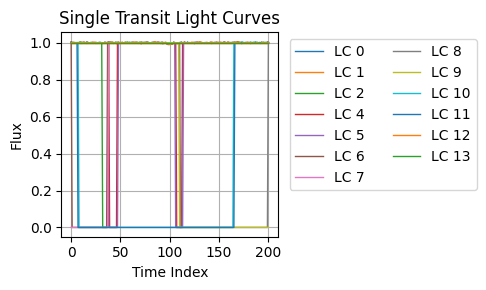

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# load and flatten your data
x = np.array(example_data['sample_segments_view']).ravel()

# constants
n_curves = 14
n_points = 201
assert x.size == n_curves * n_points, "Unexpected array size"

# extract each curve by taking every 14th point
curves = np.vstack([x[i::n_curves] for i in range(n_curves)])

# plot
plt.figure(figsize=(5, 3))
for idx, lc in enumerate(curves):
    if idx!=3:
        plt.plot(lc, label=f"LC {idx}",linewidth=1, alpha=1)
plt.title("Single Transit Light Curves")
plt.xlabel("Time Index")
plt.ylabel("Flux")
plt.grid(True)
plt.legend(ncol=2, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [8]:
# 2) interleaved: take every 14th point starting at offset i
interleaved = np.vstack([x[i::14] for i in [5,6,7,8,0]])
plot_curves(interleaved, "14 Individual Transits")


NameError: name 'plot_curves' is not defined

Scalar Features:
  astro_id: 3141


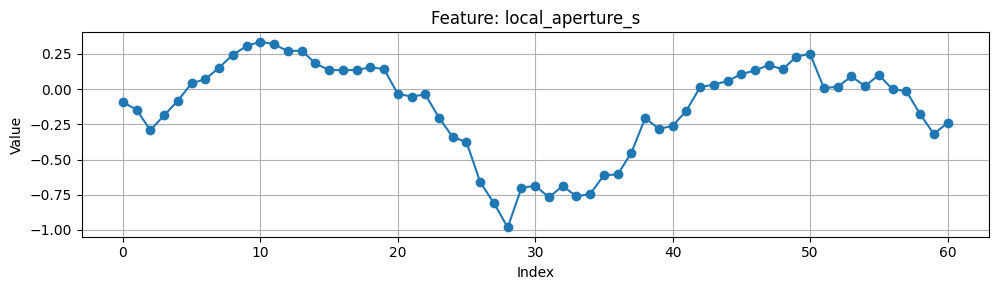

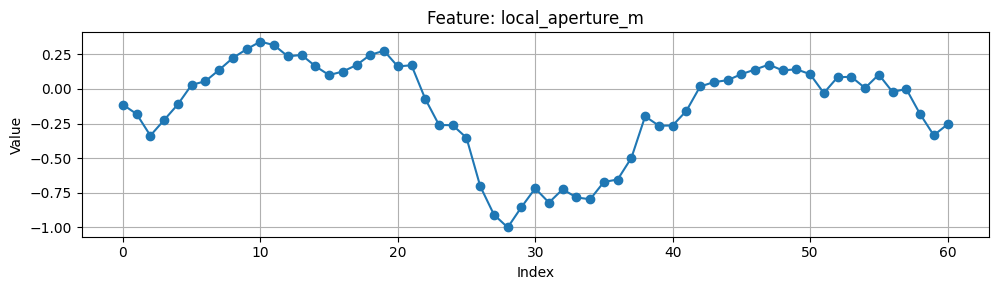

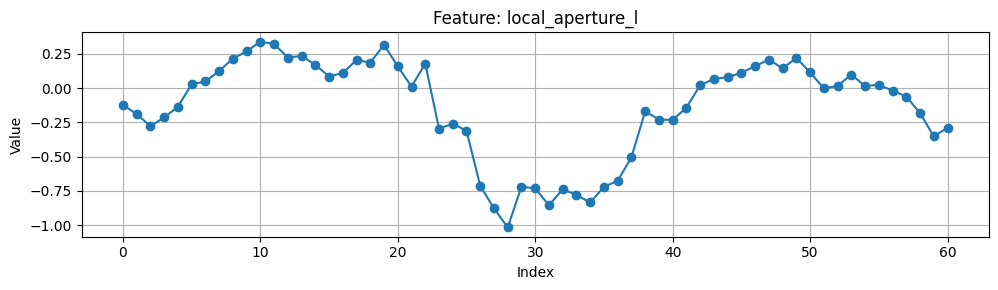

In [18]:
features_list=['astro_id','local_aperture_s','local_aperture_m','local_aperture_l']

inspect_features(features_list)

---


Now let's load two different sets of tfrecords and compare the distribution of features

In [1]:
# %%
import os
import tensorflow as tf
import matplotlib.pyplot as plt
from glob import glob

2025-05-22 11:46:15.341870: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-22 11:46:16.571526: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
PATH1="/pdo/users/pablomer/mnt/tess/astronet/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-train/" # there is different files in  this path called 00000-of-00005,00001-of-00005,00002-of-00005,00003-of-00005,00004-of-00005
PATH2="/pdo/users/dimond/mnt/tess/astronet/tfrecords-vetting-sector86-all-test/" # there is also different file sin this folder

In [5]:
def get_tfrecord_files(path):
    files = sorted(glob(os.path.join(path, "*")))
    # Drop one that says 'problematic'
    list_of_files = [f for f in files if "problematic" not in f]
    return list_of_files


In [6]:
get_tfrecord_files(PATH1)

['/pdo/users/pablomer/mnt/tess/astronet/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-train/00000-of-00005',
 '/pdo/users/pablomer/mnt/tess/astronet/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-train/00001-of-00005',
 '/pdo/users/pablomer/mnt/tess/astronet/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-train/00002-of-00005',
 '/pdo/users/pablomer/mnt/tess/astronet/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-train/00003-of-00005',
 '/pdo/users/pablomer/mnt/tess/astronet/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-train/00004-of-00005']

In [9]:
# %%
def load_feature_across_dataset(tfrecord_files, feature_name, max_examples=15000):
    values = []
    for raw_record in tf.data.TFRecordDataset(tfrecord_files).take(max_examples):
        ex = tf.train.Example()
        ex.ParseFromString(raw_record.numpy())
        f = ex.features.feature.get(feature_name, None)
        if f is not None:
            if f.HasField("float_list"):
                values.append(list(f.float_list.value))
            elif f.HasField("int64_list"):
                values.append(list(f.int64_list.value))
            elif f.HasField("bytes_list"):
                values.append([v.decode("utf-8") for v in f.bytes_list.value])
    return values


2025-05-22 11:52:28.608037: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [5]
	 [[{{node Placeholder/_0}}]]
2025-05-22 11:52:30.243473: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [25]
	 [[{{node Placeholder/_0}}]]


Dataset 1: 12375 examples
Dataset 2: 3309 examples


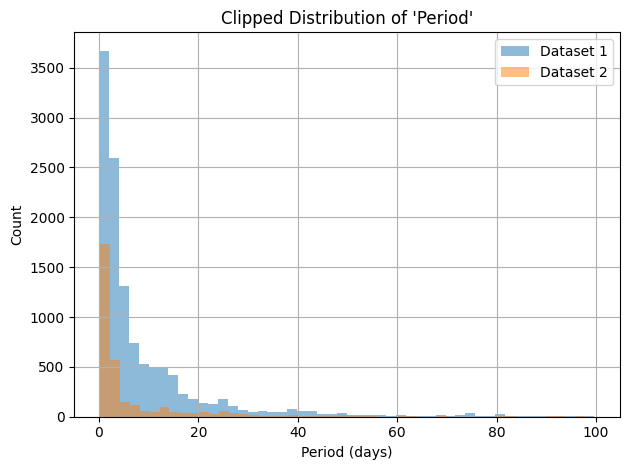

In [29]:
# Example usage
files1 = get_tfrecord_files(PATH1)
files2 = get_tfrecord_files(PATH2)

feature_to_compare = "Period"
data1 = load_feature_across_dataset(files1, feature_to_compare)
data2 = load_feature_across_dataset(files2, feature_to_compare)

print(f"Dataset 1: {len(data1)} examples")
print(f"Dataset 2: {len(data2)} examples")

# Flatten and plot histograms
import numpy as np
flat1 = np.array([item[0] for item in data1 if item])
flat2 = np.array([item[0] for item in data2 if item])

max_display_value = 100  # Only show periods <= 100 days
flat1_clip = flat1[flat1 <= max_display_value]
flat2_clip = flat2[flat2 <= max_display_value]

plt.hist(flat1_clip, bins=50, alpha=0.5, label='Dataset 1')
plt.hist(flat2_clip, bins=50, alpha=0.5, label='Dataset 2')
plt.title("Clipped Distribution of 'Period'")
plt.xlabel("Period (days)")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

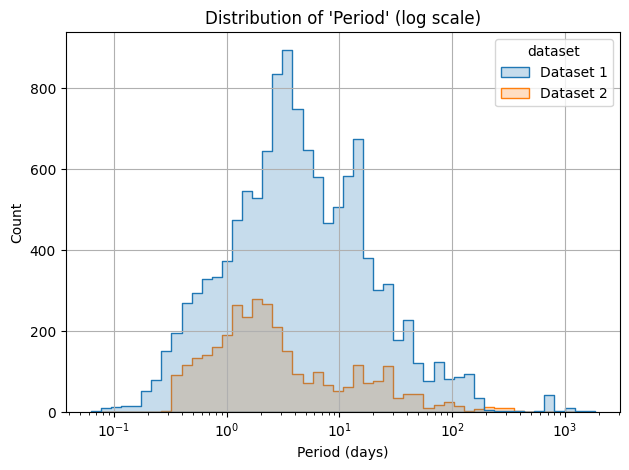

In [30]:
import seaborn as sns
import pandas as pd

# Combine both datasets into a DataFrame
df = pd.DataFrame({
    "value": np.concatenate([flat1, flat2]),
    "dataset": ["Dataset 1"] * len(flat1) + ["Dataset 2"] * len(flat2)
})

# Plot with log-scaled x-axis
sns.histplot(data=df, x="value", hue="dataset", element="step", bins=50, log_scale=(True, False))
plt.title("Distribution of 'Period' (log scale)")
plt.xlabel("Period (days)")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()


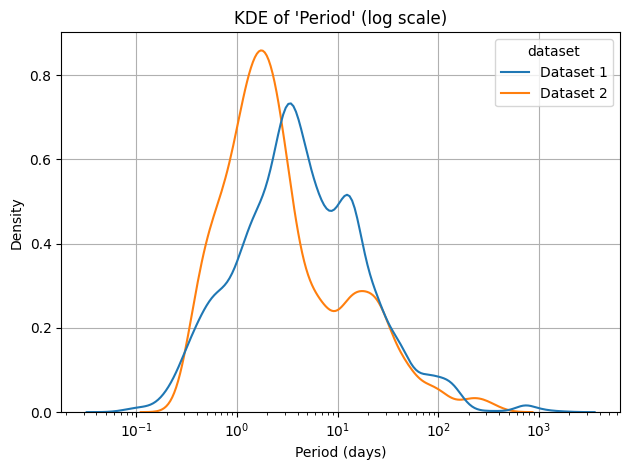

In [31]:
sns.kdeplot(data=df, x="value", hue="dataset", common_norm=False, log_scale=True)
plt.title("KDE of 'Period' (log scale)")
plt.xlabel("Period (days)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [25]:
len(data1), len(data2)

(1000, 662)

In [ ]:
features_list = [
    # Basic TCE metadata:
    'astro_id',
    'Period',
    'Duration',
    'Transit_Depth',
    'Tmag',
    'n_points',
    'n_folds',

    # Disposition / diagnostic flags:
    'disp_p', 'disp_b', 'disp_e', 'disp_n', 'disp_t', 'disp_u', 'disp_j',

    # Star properties:
    'star_mass', 'star_mass_present',
    'star_rad', 'star_rad_present',
    'star_rad_est', 'star_rad_est_present',

    # Global views:
    'global_view', 'global_std', 'global_mask', 'global_transit_mask',
    'global_view_0.3', 'global_std_0.3', 'global_mask_0.3',
    'global_view_5.0', 'global_std_5.0', 'global_mask_5.0',
    'global_view_half_period', 'global_view_half_period_0.3', 'global_view_half_period_5.0',
    'global_view_double_period',
    'global_view_double_period_mask',
    'global_view_double_period_mask_0.3',
    'global_view_double_period_mask_5.0',
    'global_view_double_period_std',
    'global_view_double_period_std_0.3',
    'global_view_double_period_std_5.0',

    # Local views:
    'local_view', 'local_std', 'local_mask',
    'local_scale', 'local_scale_present',
    'local_view_even', 'local_std_even', 'local_mask_even',
    'local_view_odd', 'local_std_odd', 'local_mask_odd',
    'local_view_0.3', 'local_std_0.3', 'local_mask_0.3',
    'local_view_5.0', 'local_std_5.0', 'local_mask_5.0',

    # Local views - half period:
    'local_view_half_period',
    'local_view_half_period_0.3', 'local_view_half_period_5.0',
    'local_view_half_period_std',
    'local_view_half_period_std_0.3',
    'local_view_half_period_mask',
    'local_view_half_period_mask_0.3', 'local_view_half_period_mask_5.0',

    # Aperture views:
    'local_aperture_s', 'local_aperture_s_0.3',
    'local_aperture_l', 'local_aperture_l_0.3', 'local_aperture_l_5.0',
    'local_aperture_m', 'local_aperture_m_0.3', 'local_aperture_m_5.0',

    # Secondary views:
    'secondary_view', 'secondary_view_0.3', 'secondary_view_5.0',
    'secondary_std', 'secondary_std_0.3', 'secondary_std_5.0',
    'secondary_mask', 'secondary_mask_0.3', 'secondary_mask_5.0',
    'secondary_scale', 'secondary_scale_0.3', 'secondary_scale_5.0',
    'secondary_scale_present', 'secondary_scale_present_0.3', 'secondary_scale_present_5.0',
    'secondary_phase', 'secondary_phase_0.3', 'secondary_phase_5.0',

    # Sample segments:
    'sample_segments_view', 'sample_segments_view_0.3', 'sample_segments_view_5.0',
    'sample_segments_local_view', 'sample_segments_local_view_0.3', 'sample_segments_local_view_5.0',

    # Miscellaneous:
    'global_transit_mask', 'global_transit_mask_5.0',
]

In [ ]:
# Take '/pdo/users/dimond/mnt/tess/astronet/tfrecords-vetting-sector86-all-test/00000-of-00025' and print all the key names
tfrecord_files = [
    "/pdo/users/dimond/mnt/tess/astronet/tfrecords-vetting-sector86-all-test/00000-of-00025"
]
raw_dataset = tf.data.TFRecordDataset(tfrecord_files)
for raw_record in raw_dataset.take(1):
    example = tf.train.Example()
    example.ParseFromString(raw_record.numpy())

    for key, feature in example.features.feature.items():
       print(key)


local_view
local_aperture_l
local_scale_present
secondary_std
local_scale_present_0.3
local_std
global_view_double_period
star_mass_present
local_std_even
global_view_half_period_0.3
local_view_half_period_0.3
local_mask
secondary_view_0.3
global_view_double_period_mask_0.3
global_view_double_period_mask
local_aperture_m_0.3
global_view_0.3
astro_id
local_std_odd
local_view_odd
global_view_double_period_std_0.3
local_std_odd_0.3
local_aperture_l_5.0
global_view_half_period
star_rad
global_view_double_period_mask_5.0
secondary_scale_5.0
global_mask_5.0
local_mask_odd
global_view_half_period_std
local_mask_5.0
local_view_half_period_5.0
star_rad_est
local_view_half_period_std_5.0
global_view_half_period_5.0
secondary_view_5.0
local_view_odd_5.0
local_std_even_5.0
local_view_even_5.0
local_view_even
global_transit_mask_5.0
global_view_half_period_mask_0.3
secondary_scale_present_0.3
global_transit_mask
local_view_even_0.3
local_aperture_l_0.3
global_view_double_period_std
global_mask_0.3


2025-05-21 18:53:25.338317: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1]
	 [[{{node Placeholder/_0}}]]


Systematic study:

2025-05-22 14:31:35.004332: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [5]
	 [[{{node Placeholder/_0}}]]
2025-05-22 14:31:36.854410: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [25]
	 [[{{node Placeholder/_0}}]]
2025-05-22 14:31:37.413863: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [5]
	 [[{{

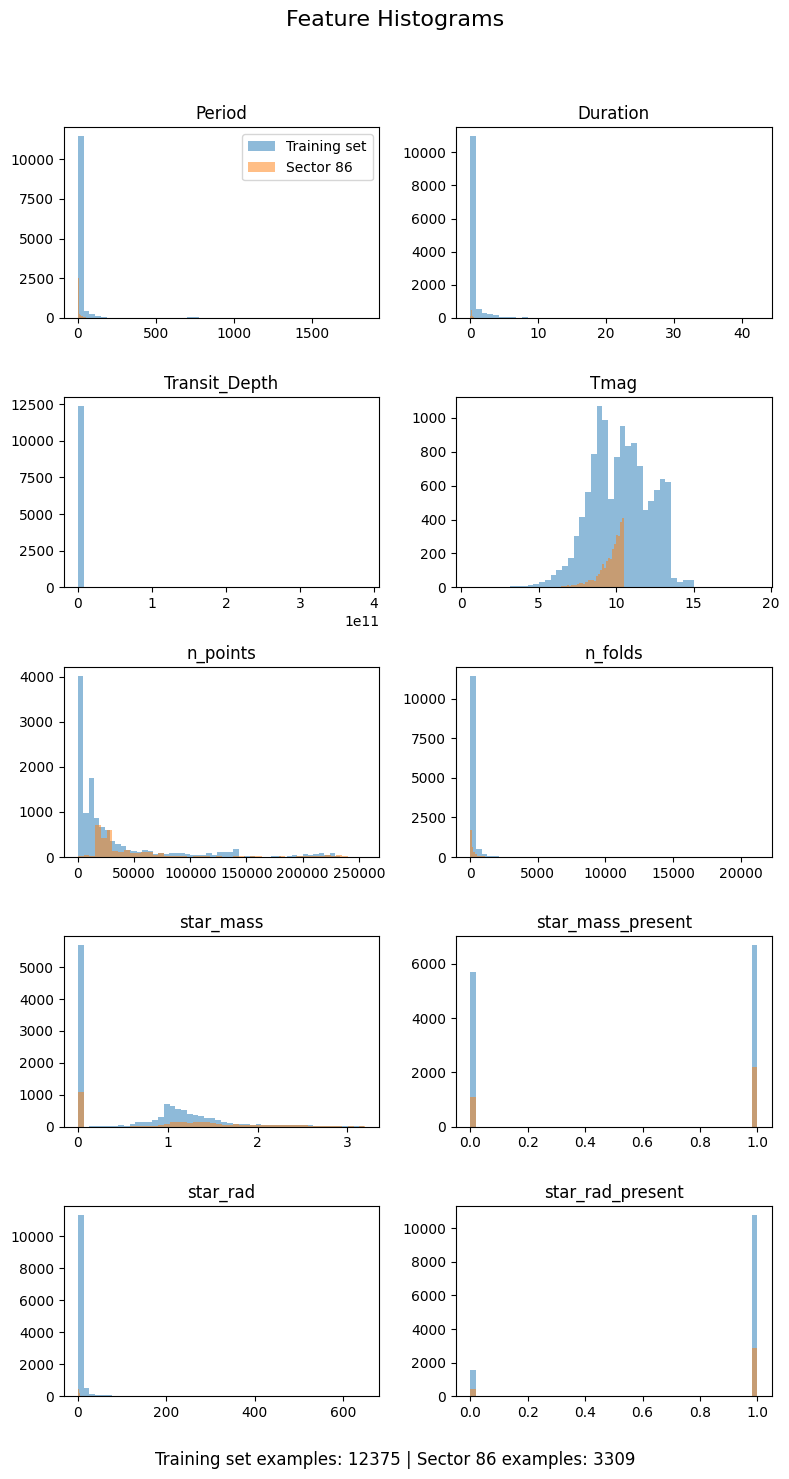

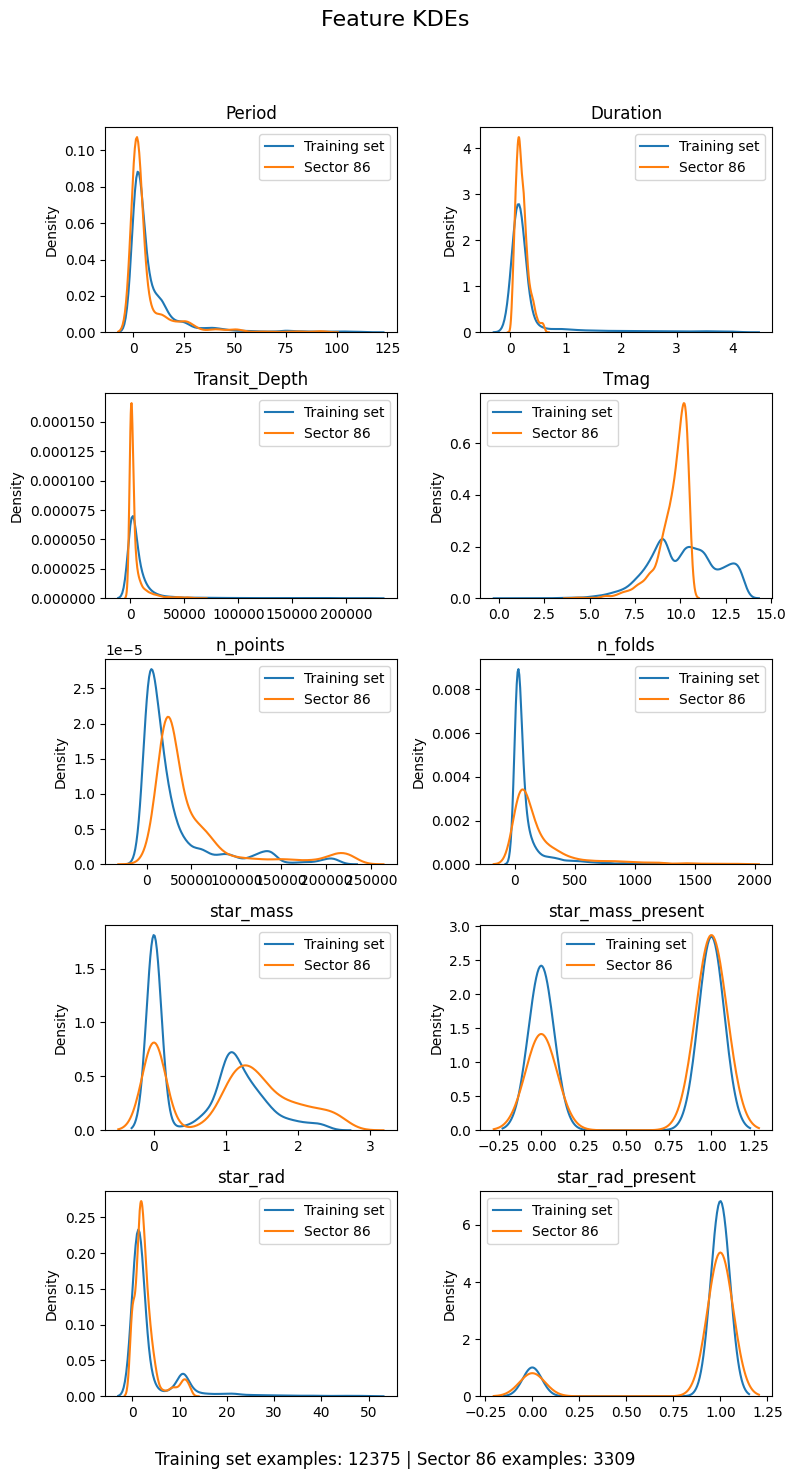

In [49]:
# %%
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

# paths
PATH1 = "/pdo/users/pablomer/mnt/tess/astronet/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-train/"
PATH2 = "/pdo/users/dimond/mnt/tess/astronet/tfrecords-vetting-sector86-all-test/"

def get_tfrecord_files(path):
    files = sorted(glob(os.path.join(path, "*")))
    return [f for f in files if "problematic" not in f]

def load_feature_across_dataset(tfrecord_files, feature_name, max_examples=15000):
    vals = []
    for raw in tf.data.TFRecordDataset(tfrecord_files).take(max_examples):
        ex = tf.train.Example()
        ex.ParseFromString(raw.numpy())
        f = ex.features.feature.get(feature_name)
        if f is None: continue
        if f.HasField("float_list"):
            vals.extend(f.float_list.value)
        elif f.HasField("int64_list"):
            vals.extend(f.int64_list.value)
        elif f.HasField("bytes_list"):
            # decode bytes to float if needed
            vals.extend([float(x.decode()) for x in f.bytes_list.value])
    return np.array(vals)

# which features to compare
features = [
    'Period','Duration','Transit_Depth','Tmag',
    'n_points','n_folds',
    'star_mass','star_mass_present',
    'star_rad','star_rad_present',
]

# load file lists
files1 = get_tfrecord_files(PATH1)
files2 = get_tfrecord_files(PATH2)

# preload all feature arrays
data = {}
for feat in features:
    a1 = load_feature_across_dataset(files1, feat)
    a2 = load_feature_across_dataset(files2, feat)
    data[feat] = (a1, a2)

# example counts (assuming scalar per record)
N1 = len(next(iter(data.values()))[0])
N2 = len(next(iter(data.values()))[1])

# layout
n = len(features)
ncols = 2
nrows = int(np.ceil(n / ncols))

# --- Figure 1: Histograms ---
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    flat1, flat2 = data[feat]
    ax.hist(flat1, bins=50, alpha=0.5, label="Training set")
    ax.hist(flat2, bins=50, alpha=0.5, label="Sector 86")
    ax.set_title(feat)
    if i == 0:
        ax.legend()
# remove any unused axes
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Feature Histograms", fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.text(0.5, 0.01,
         f"Training set examples: {N1} | Sector 86 examples: {N2}",
         ha="center", fontsize=12)
plt.show()

# --- Figure 2: KDEs ---
fig2, axes2 = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3))
axes2 = axes2.flatten()

for i, feat in enumerate(features):
    ax = axes2[i]
    flat1, flat2 = data[feat]
    # Remove outliers for better visualization
    flat1 = flat1[flat1 <= np.percentile(flat1, 98)]
    flat2 = flat2[flat2 <= np.percentile(flat2, 98)]

    #Print the feature name
    # print(feat)
    sns.kdeplot(flat1, ax=ax, label="Training set", common_norm=False, log_scale=False)
    sns.kdeplot(flat2, ax=ax, label="Sector 86", common_norm=False, log_scale=False)
    ax.set_title(feat)
    # if i == 0:
    #     ax.legend()
    # Show legend placed automatically in best location
    ax.legend(loc='best')
for j in range(i+1, len(axes2)):
    fig2.delaxes(axes2[j])

fig2.suptitle("Feature KDEs", fontsize=16)
fig2.tight_layout(rect=[0, 0.03, 1, 0.95])
fig2.text(0.5, 0.01,
          f"Training set examples: {N1} | Sector 86 examples: {N2}",
          ha="center", fontsize=12)
plt.show()


In [ ]:
features=[# Global views:
    'global_view', 'global_std', 'global_mask', 'global_transit_mask',
    'global_view_0.3', 'global_std_0.3', 'global_mask_0.3',
    'global_view_5.0', 'global_std_5.0', 'global_mask_5.0',
    'global_view_half_period', 'global_view_half_period_0.3', 'global_view_half_period_5.0',
    'global_view_double_period',
    'global_view_double_period_mask',
    'global_view_double_period_mask_0.3',
    'global_view_double_period_mask_5.0',
    'global_view_double_period_std',
    'global_view_double_period_std_0.3',
    'global_view_double_period_std_5.0',

    # Local views:
    'local_view', 'local_std', 'local_mask',
    'local_scale', 'local_scale_present',
    'local_view_even', 'local_std_even', 'local_mask_even',
    'local_view_odd', 'local_std_odd', 'local_mask_odd',
    'local_view_0.3', 'local_std_0.3', 'local_mask_0.3',
    'local_view_5.0', 'local_std_5.0', 'local_mask_5.0',

    # Local views - half period:
    'local_view_half_period',
    'local_view_half_period_0.3', 'local_view_half_period_5.0',
    'local_view_half_period_std',
    'local_view_half_period_std_0.3',
    'local_view_half_period_mask',
    'local_view_half_period_mask_0.3', 'local_view_half_period_mask_5.0',

    # Aperture views:
    'local_aperture_s', 'local_aperture_s_0.3',
    'local_aperture_l', 'local_aperture_l_0.3', 'local_aperture_l_5.0',
    'local_aperture_m', 'local_aperture_m_0.3', 'local_aperture_m_5.0',

    # Secondary views:
    'secondary_view', 'secondary_view_0.3', 'secondary_view_5.0',
    'secondary_std', 'secondary_std_0.3', 'secondary_std_5.0',
    'secondary_mask', 'secondary_mask_0.3', 'secondary_mask_5.0',
    'secondary_scale', 'secondary_scale_0.3', 'secondary_scale_5.0',
    'secondary_scale_present', 'secondary_scale_present_0.3', 'secondary_scale_present_5.0',
    'secondary_phase', 'secondary_phase_0.3', 'secondary_phase_5.0',

    # Sample segments:
    'sample_segments_view', 'sample_segments_view_0.3', 'sample_segments_view_5.0',
    'sample_segments_local_view', 'sample_segments_local_view_0.3', 'sample_segments_local_view_5.0',

    # Miscellaneous:
    'global_transit_mask', 'global_transit_mask_5.0']

0.0


# --- Time-Series Feature Metrics & KDEs ---



2025-05-22 16:06:51.858124: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [5]
	 [[{{node Placeholder/_0}}]]
2025-05-22 16:10:42.907573: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [25]
	 [[{{node Placeholder/_0}}]]


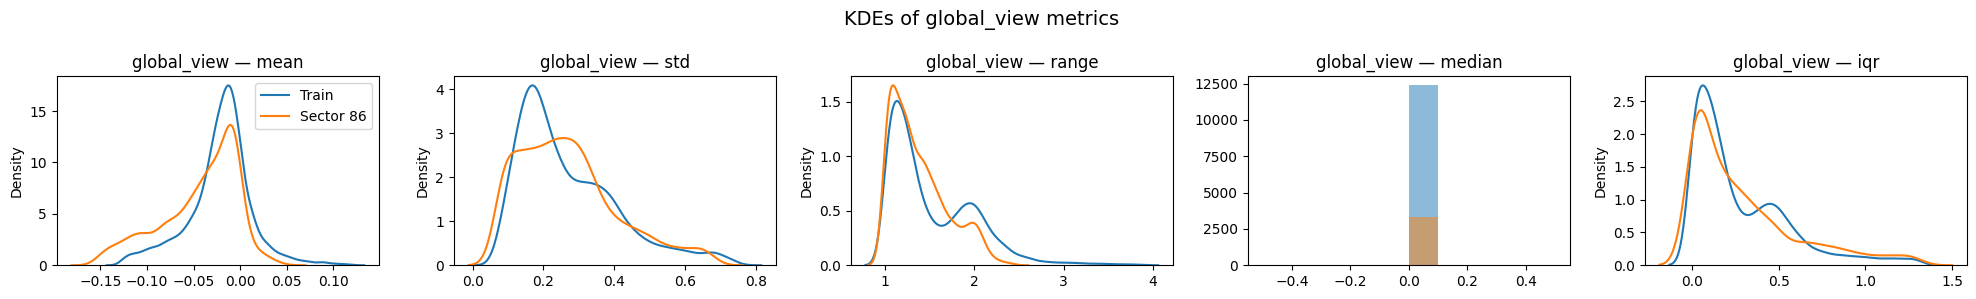

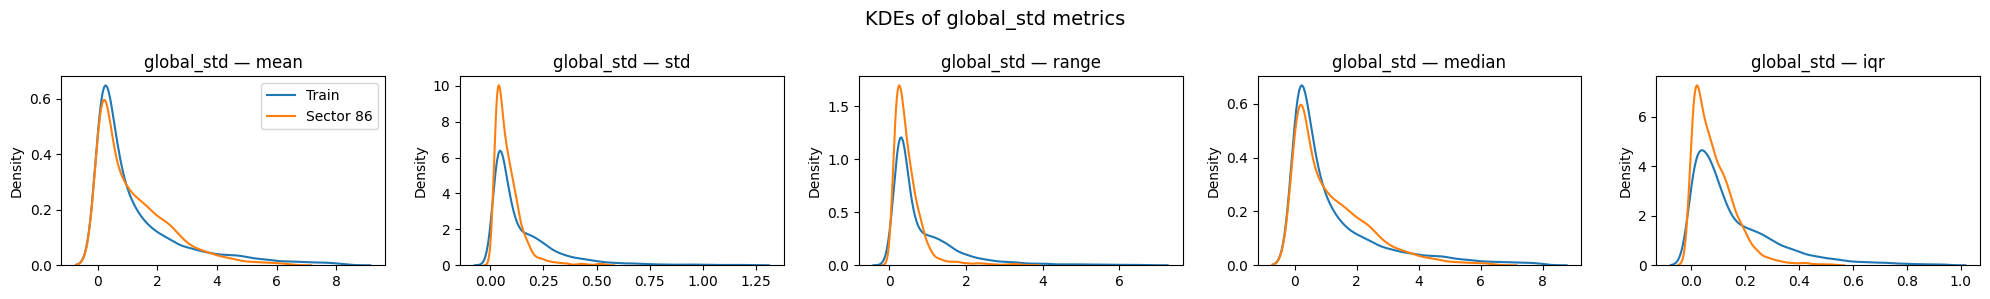

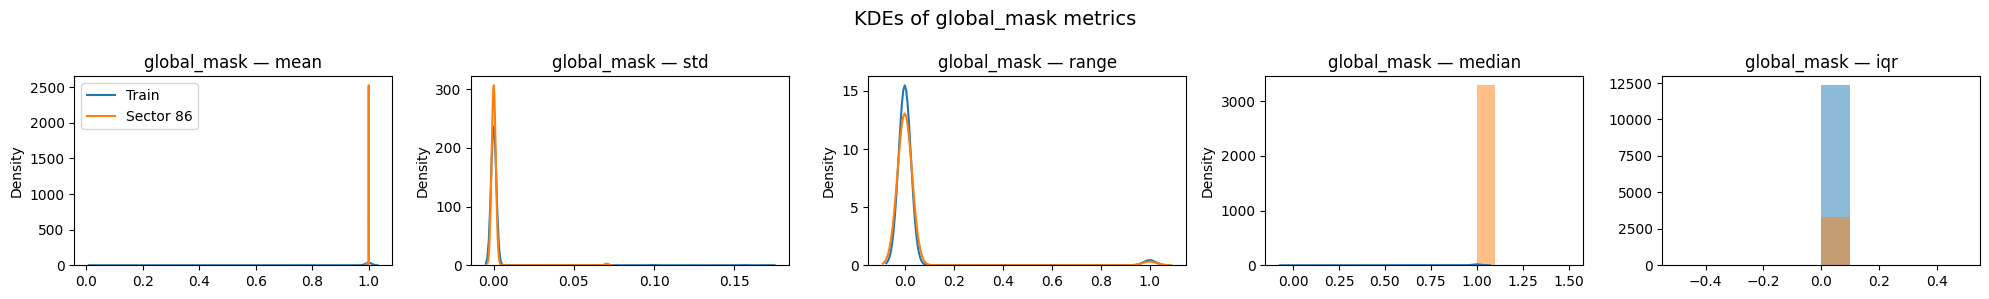

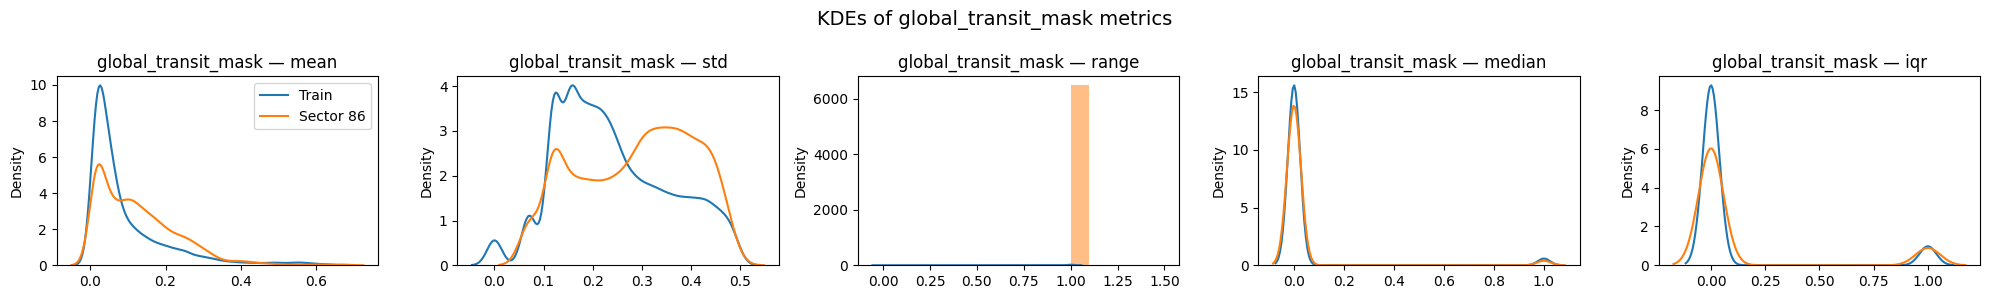

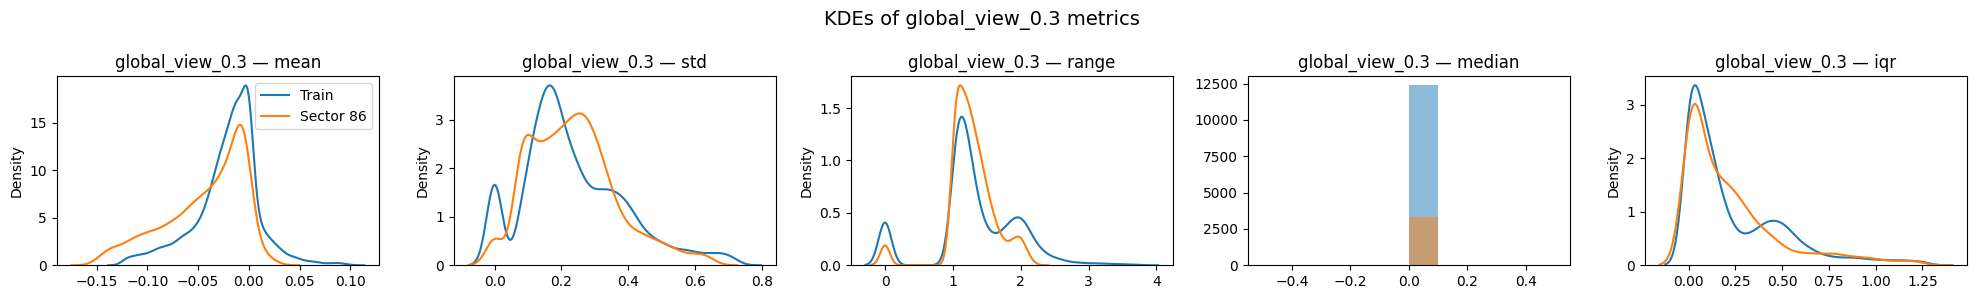

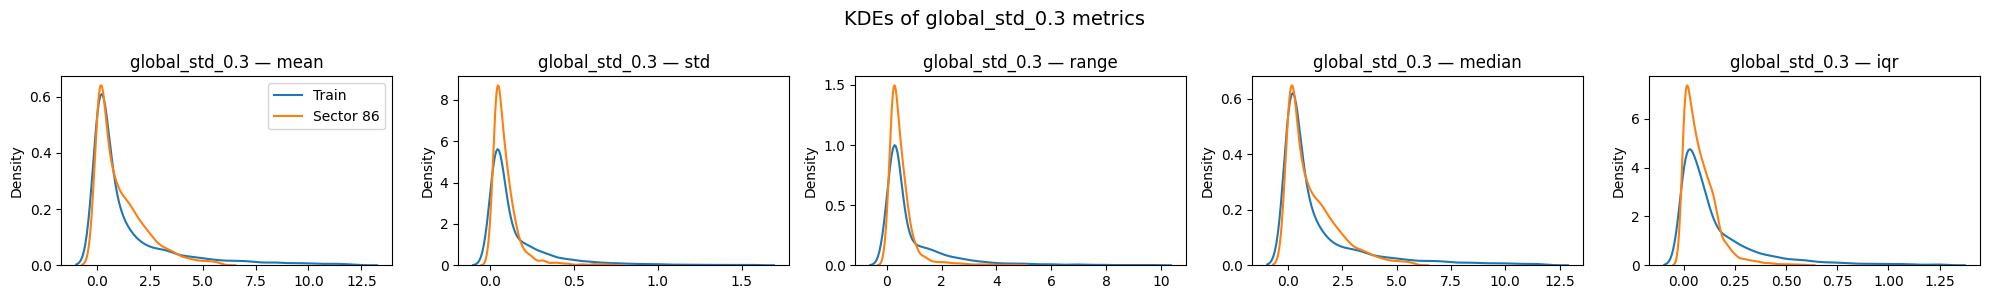

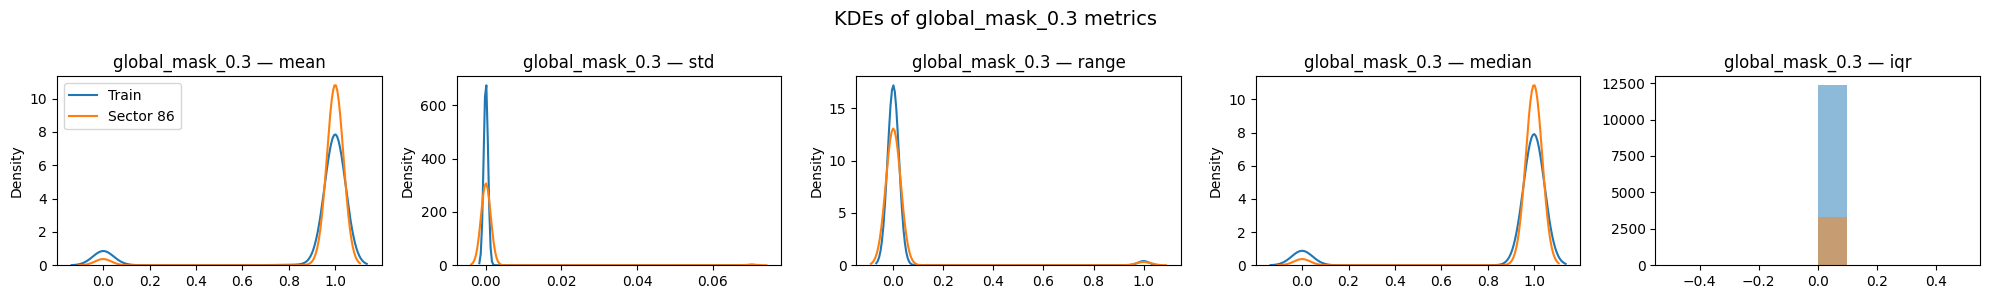

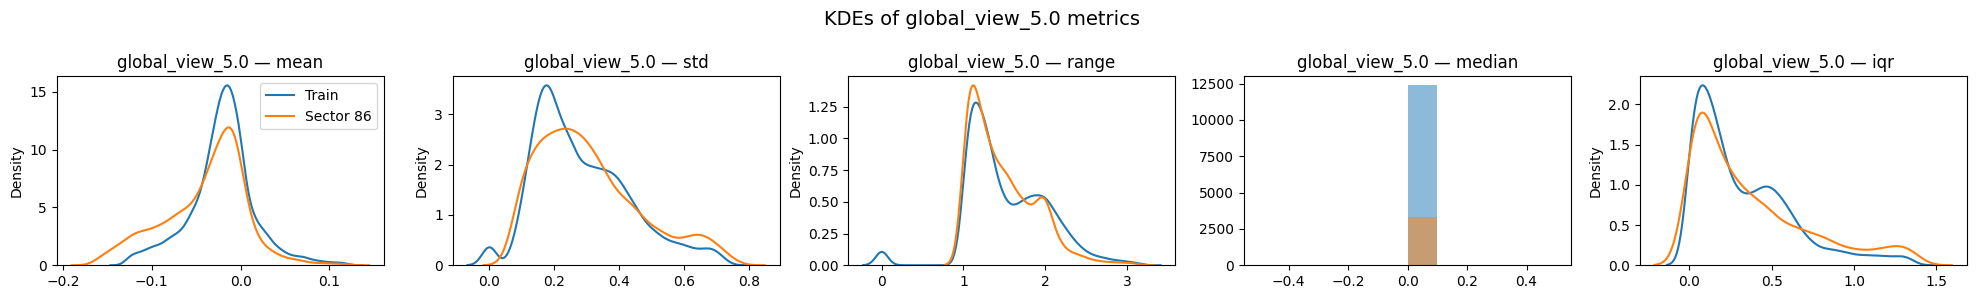

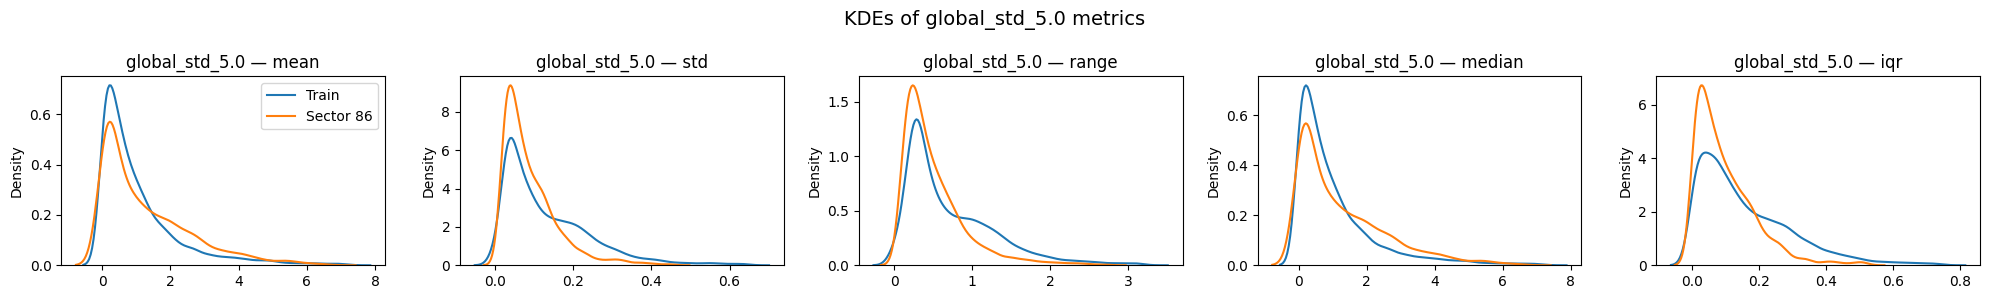

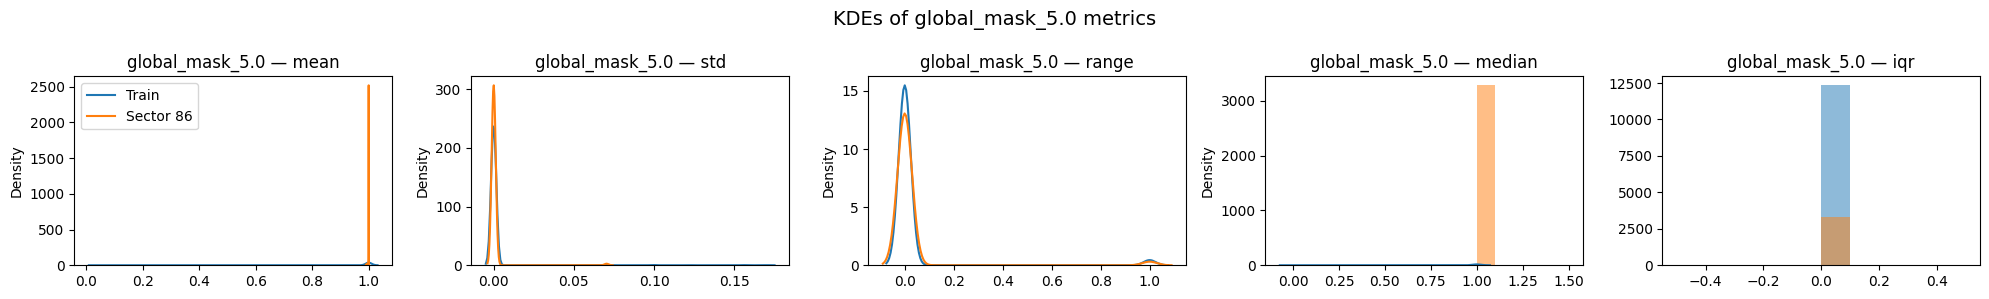

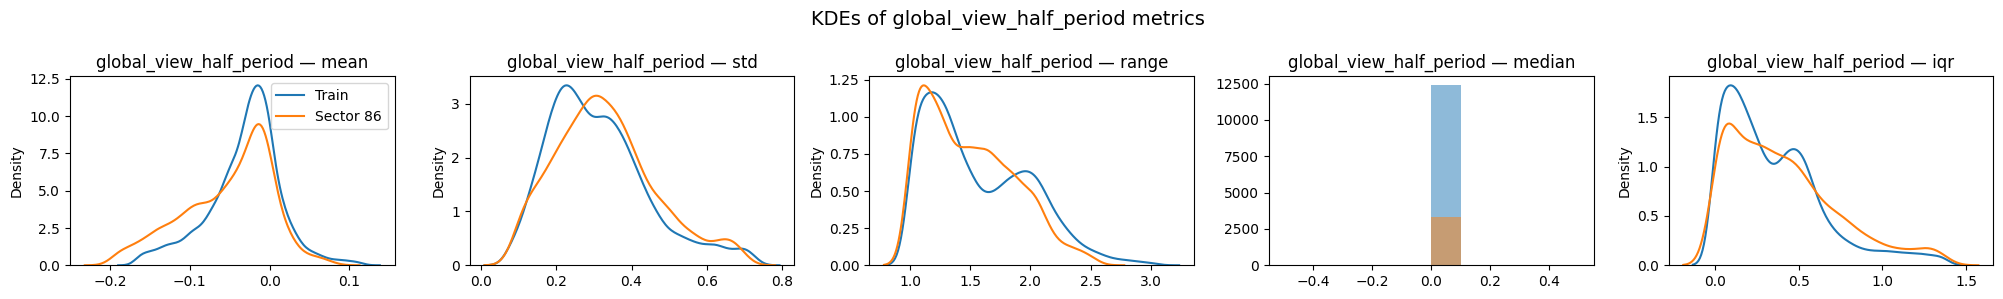

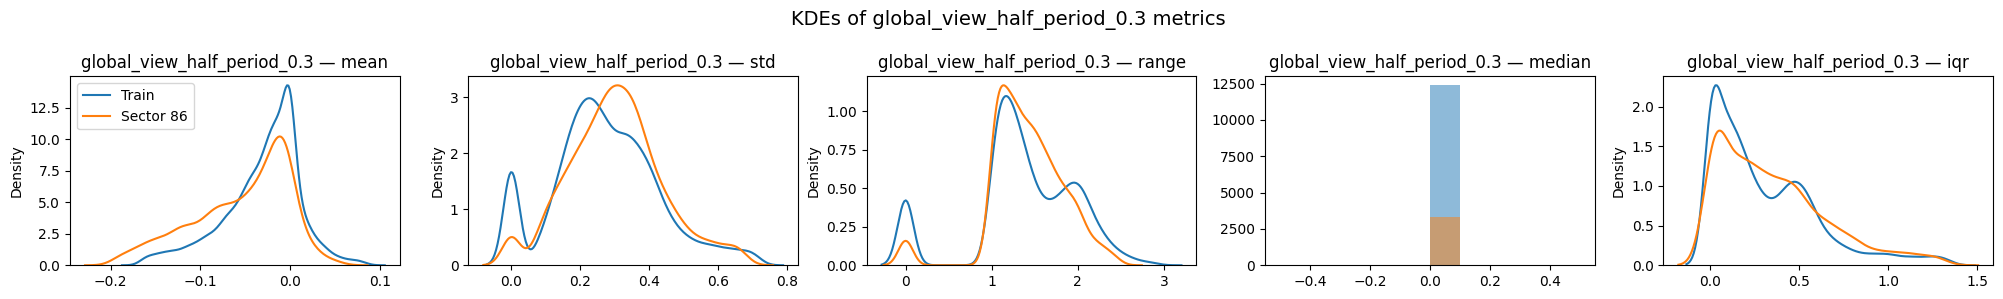

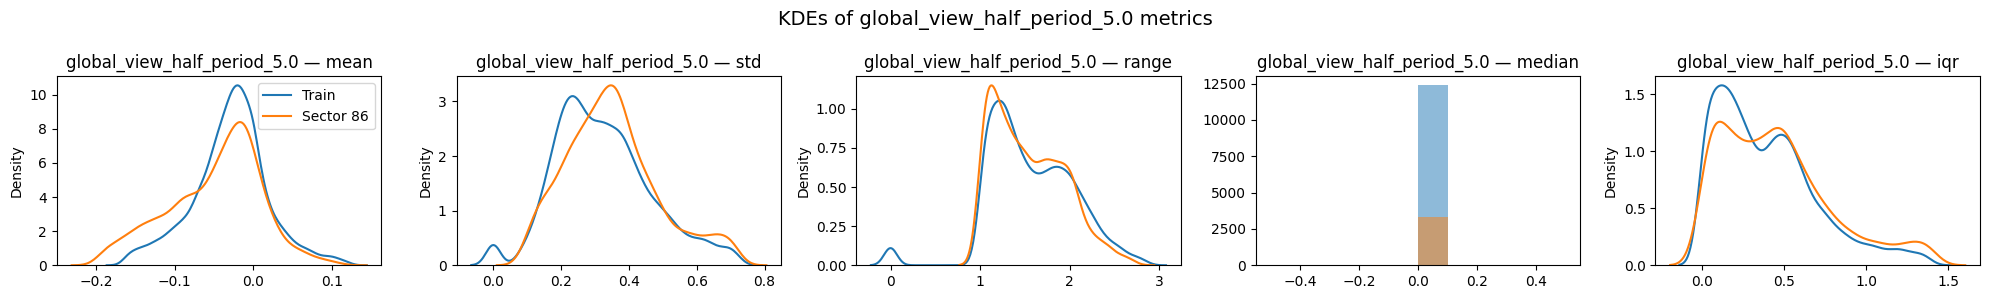

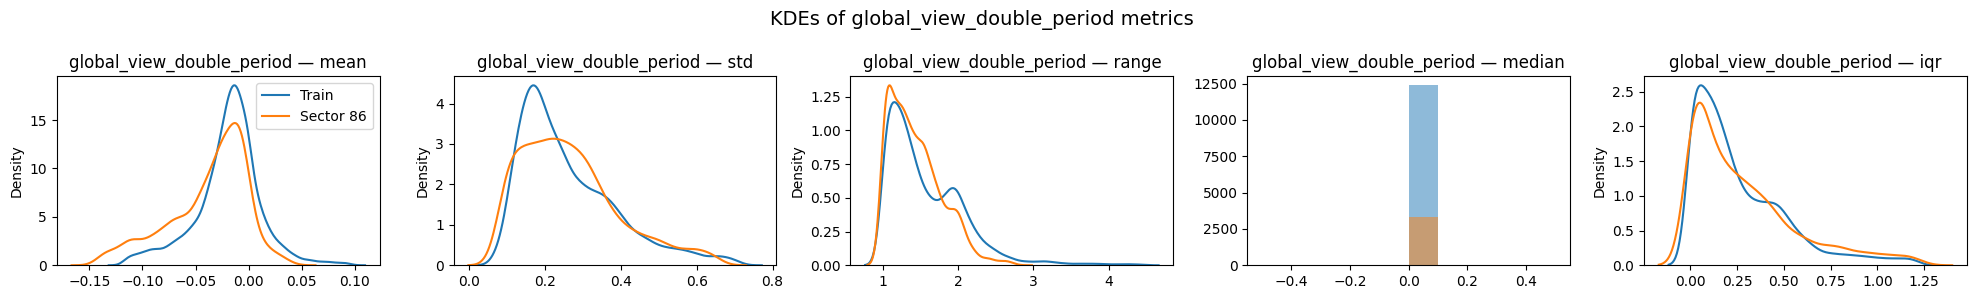

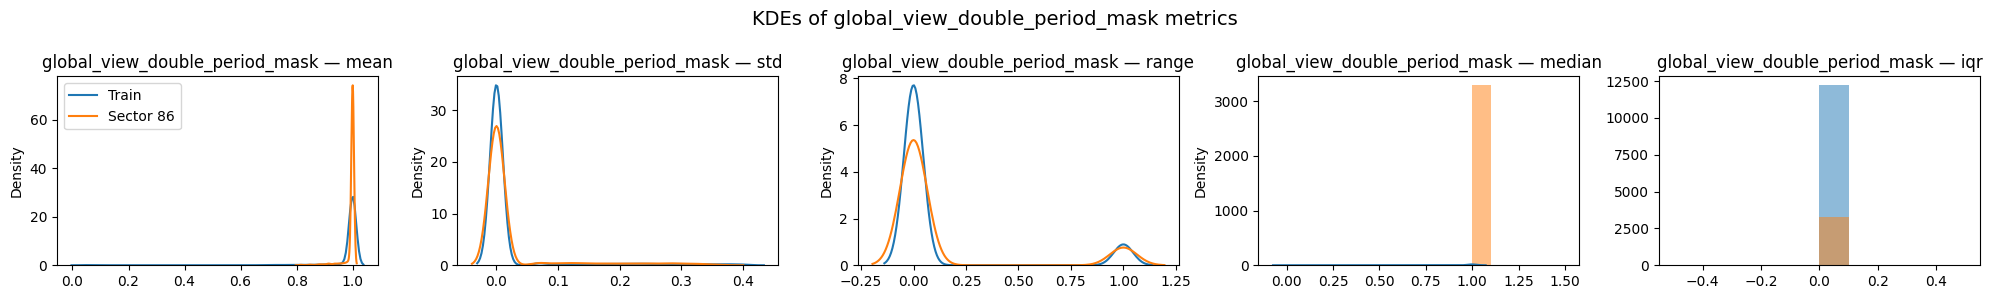

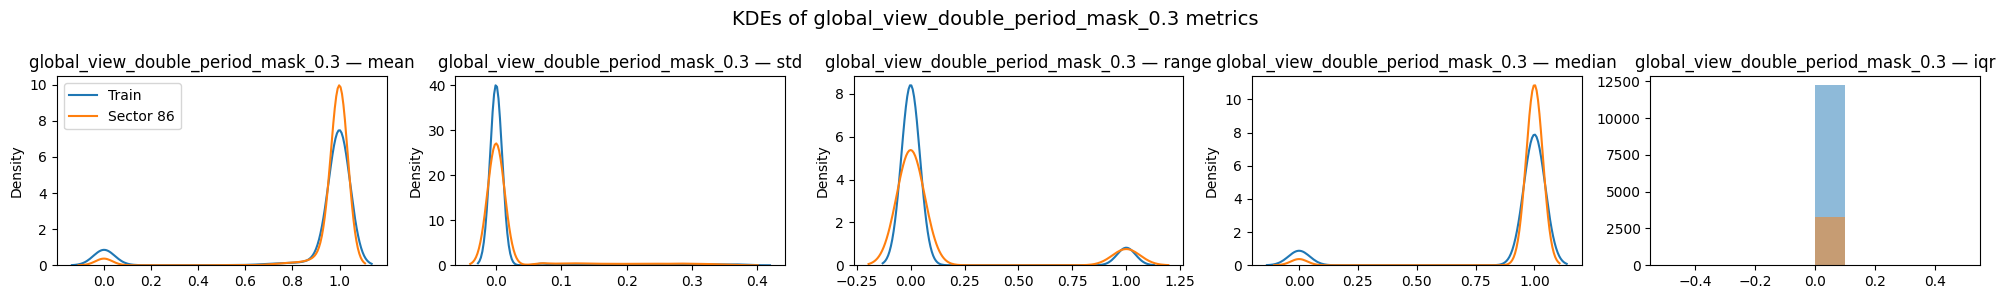

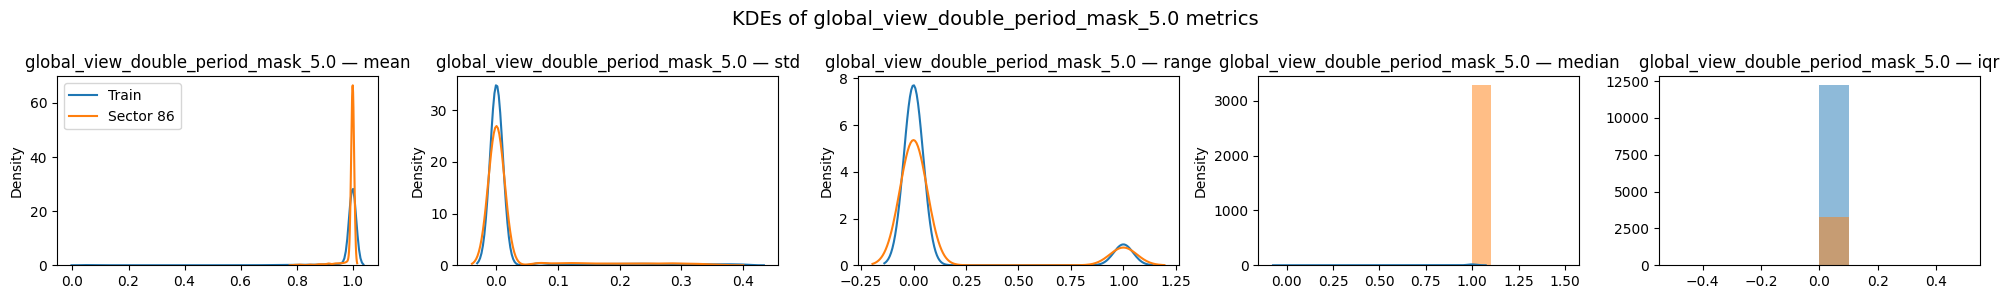

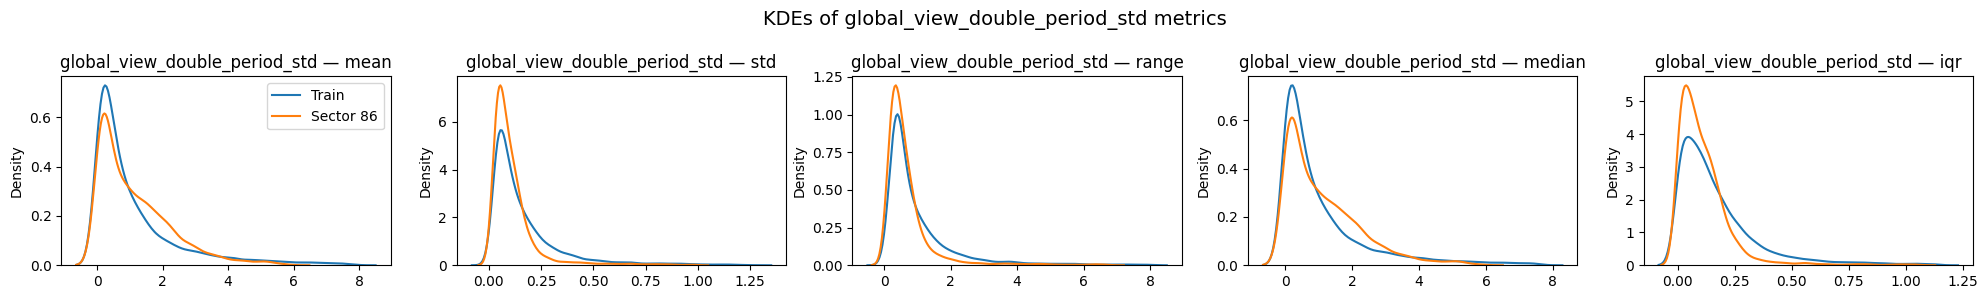

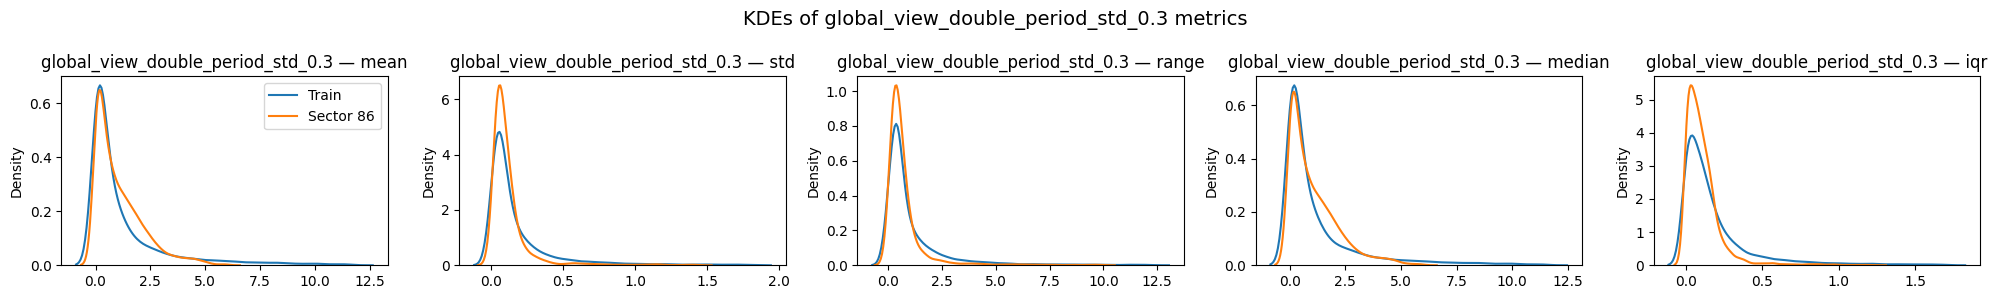

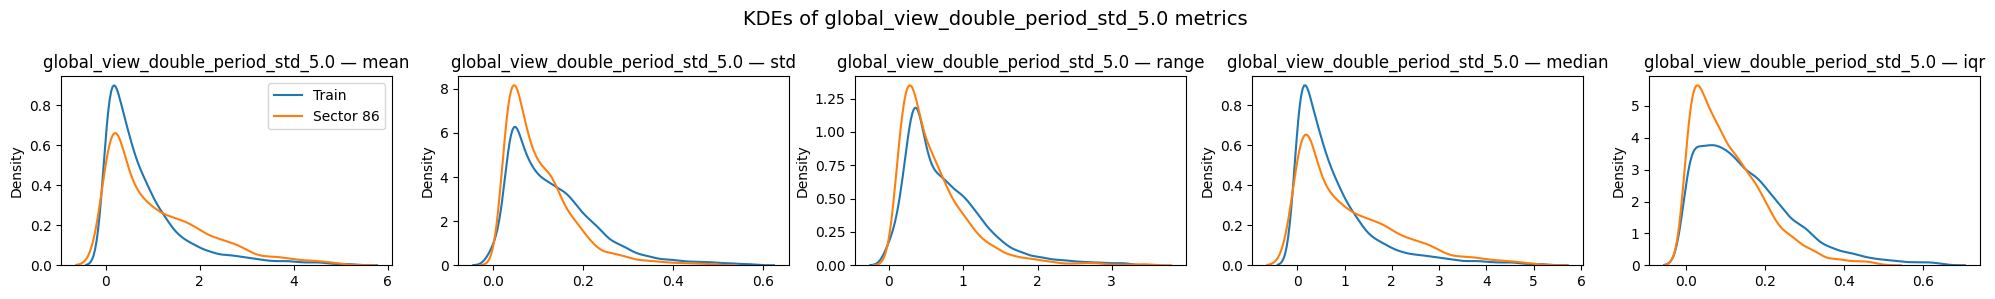

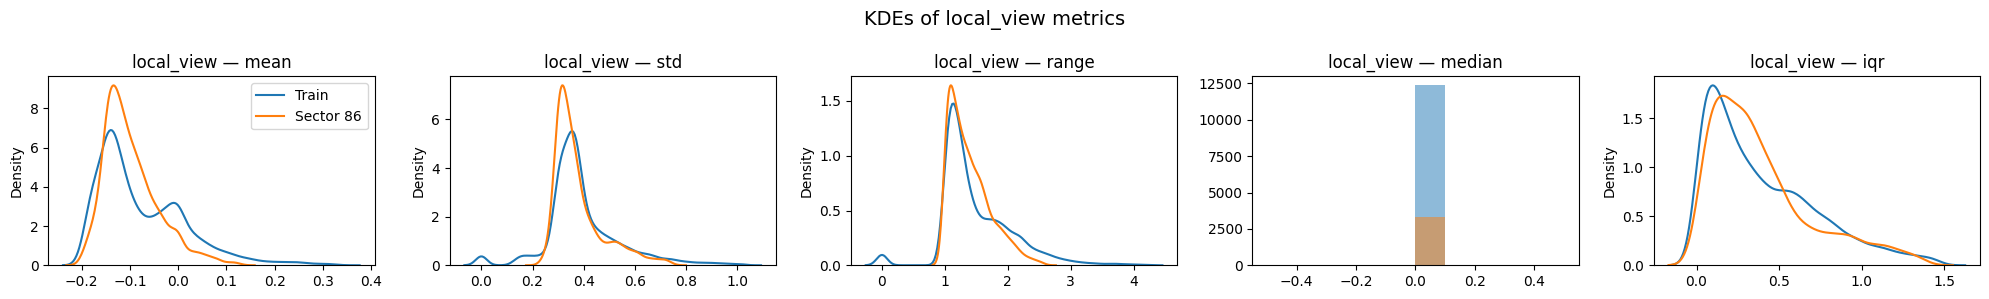

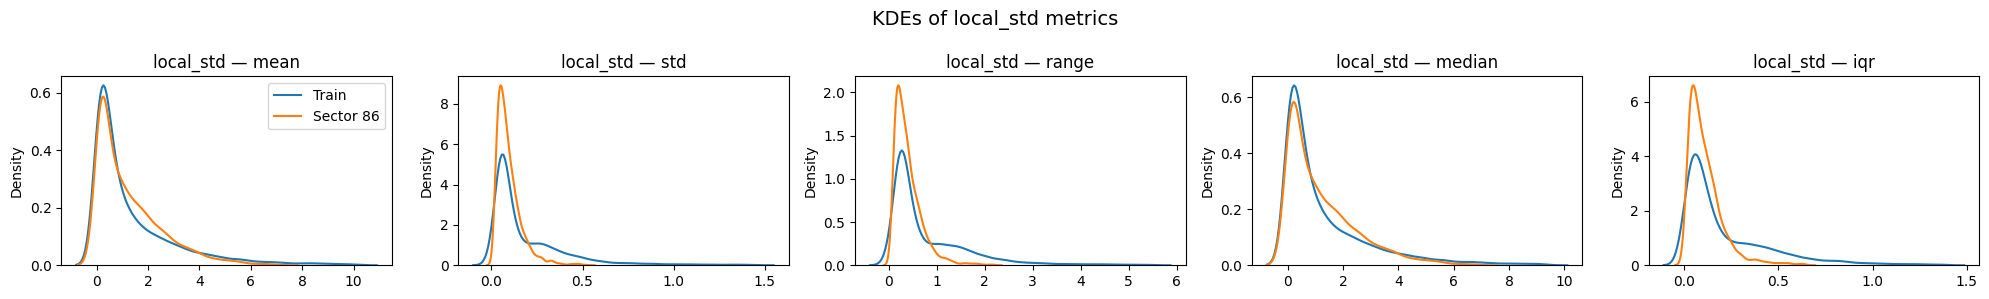

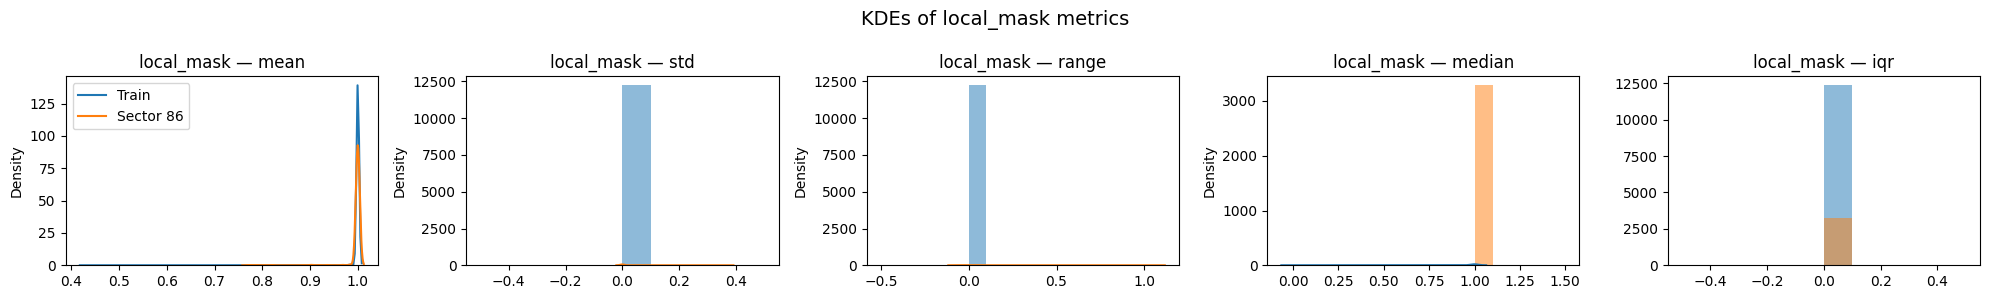

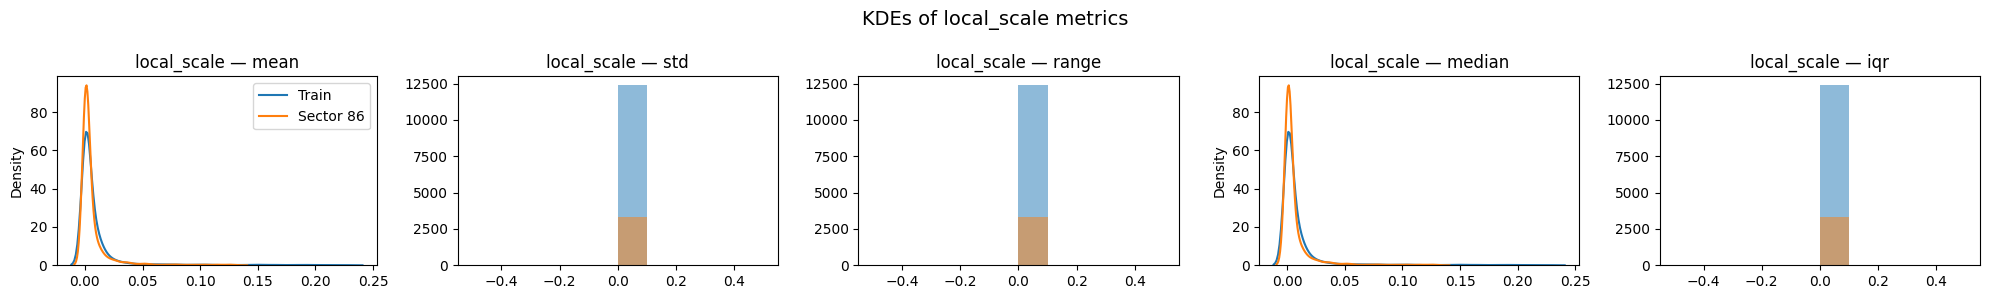

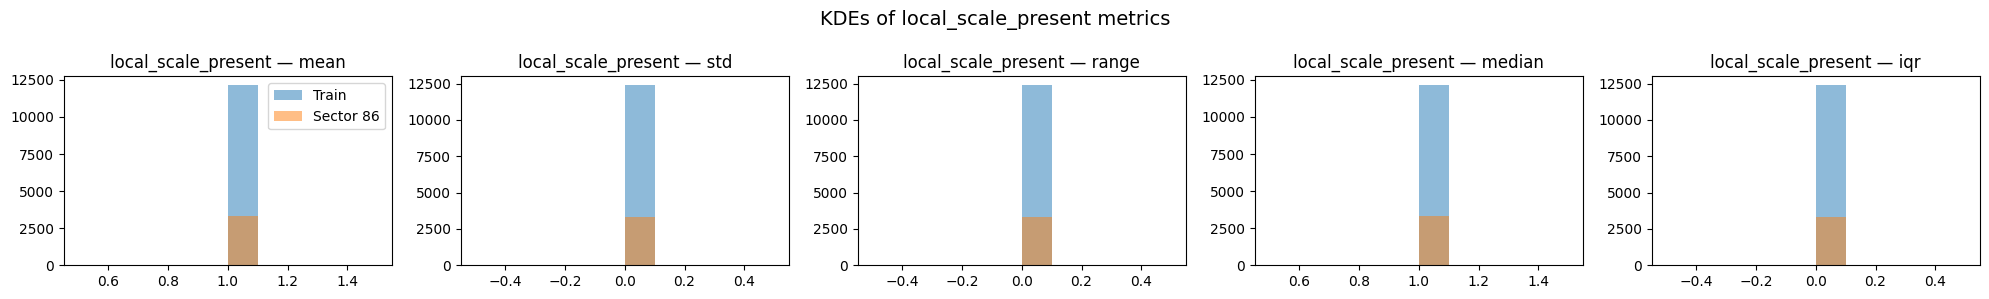

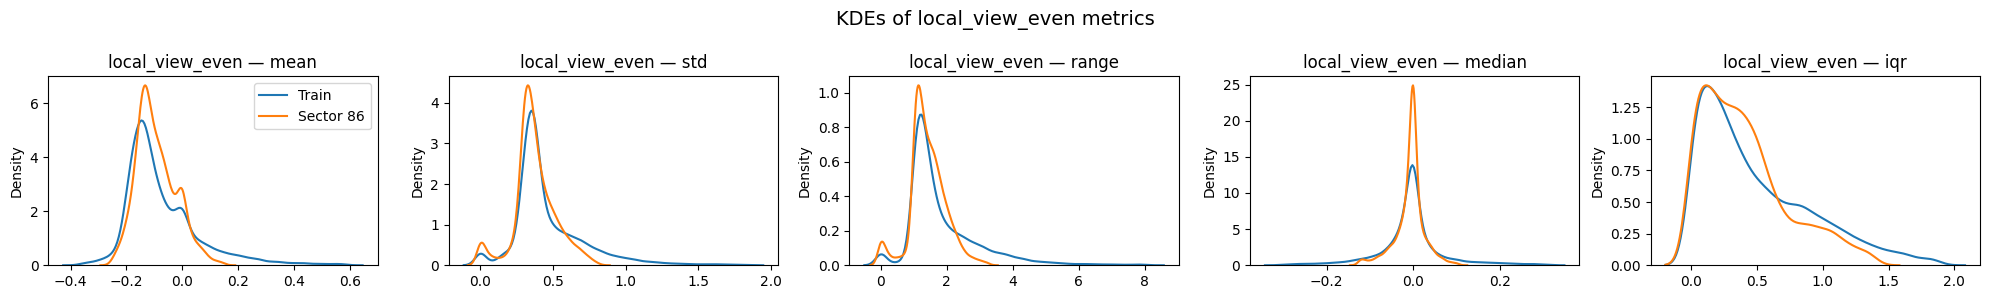

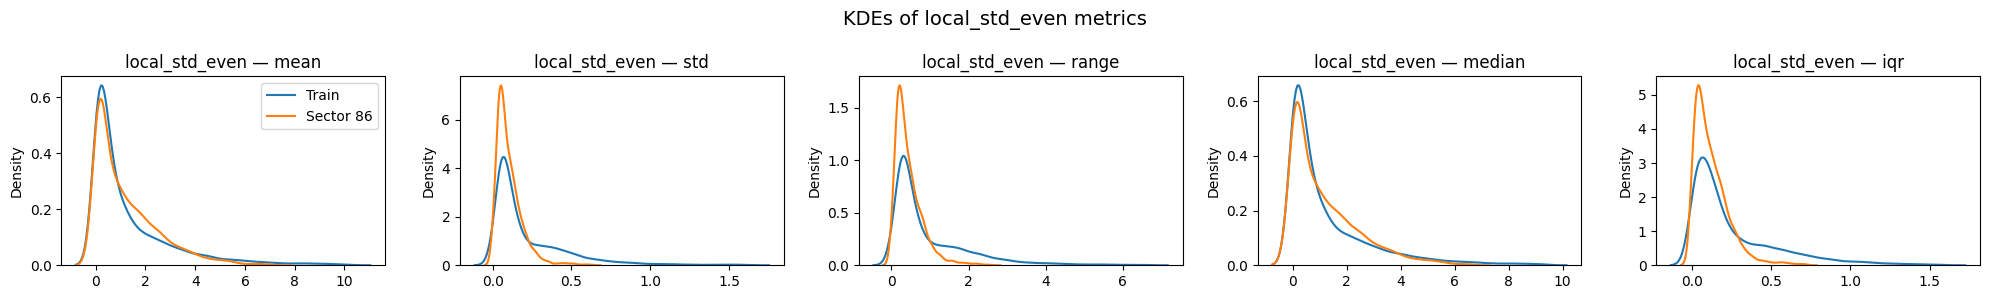

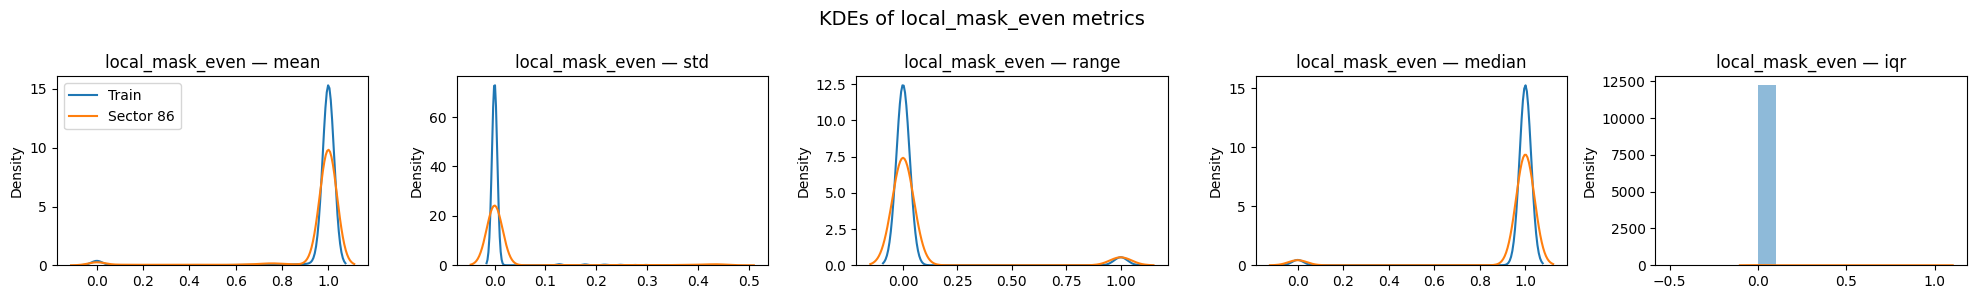

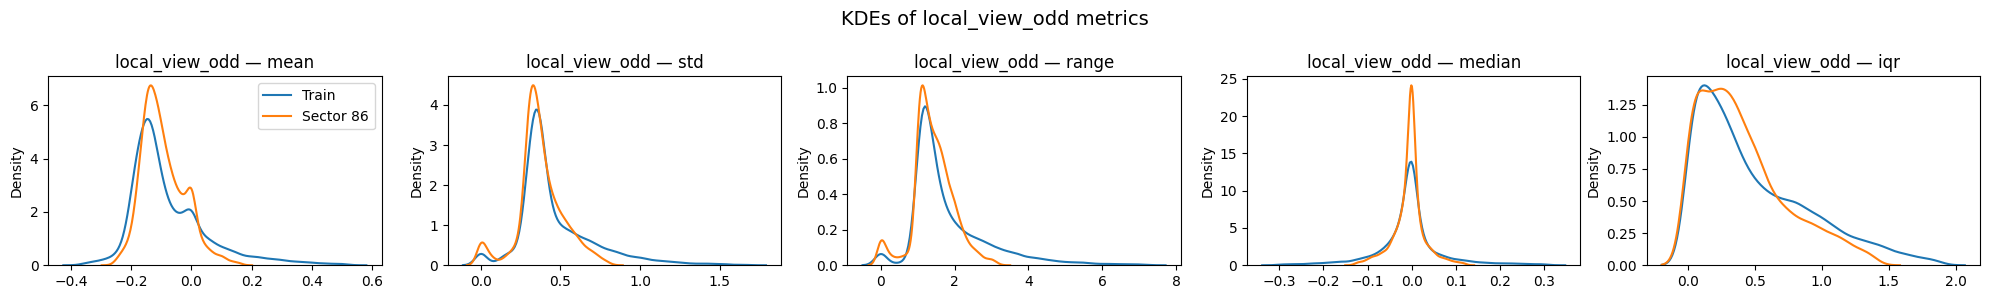

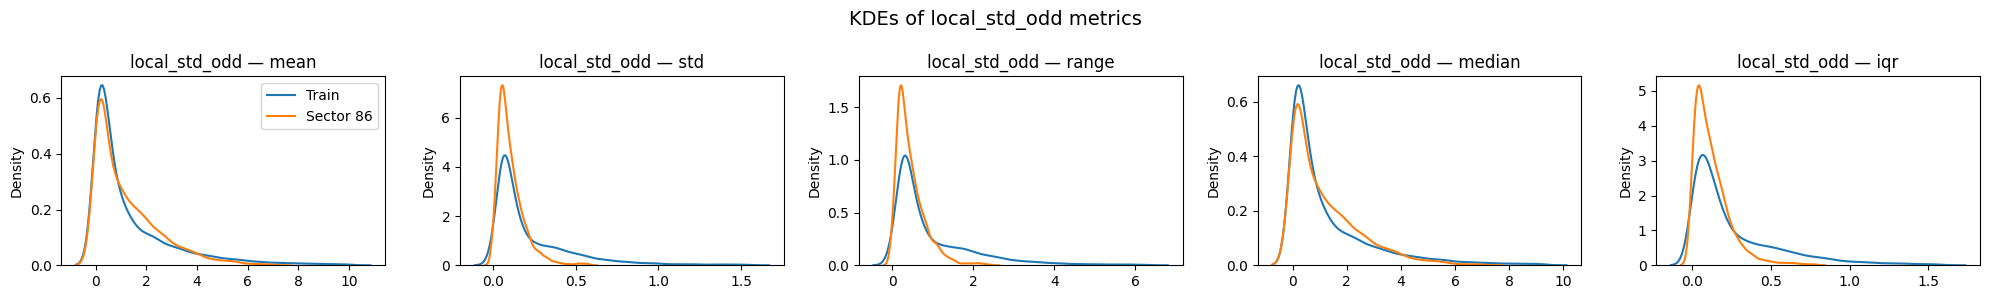

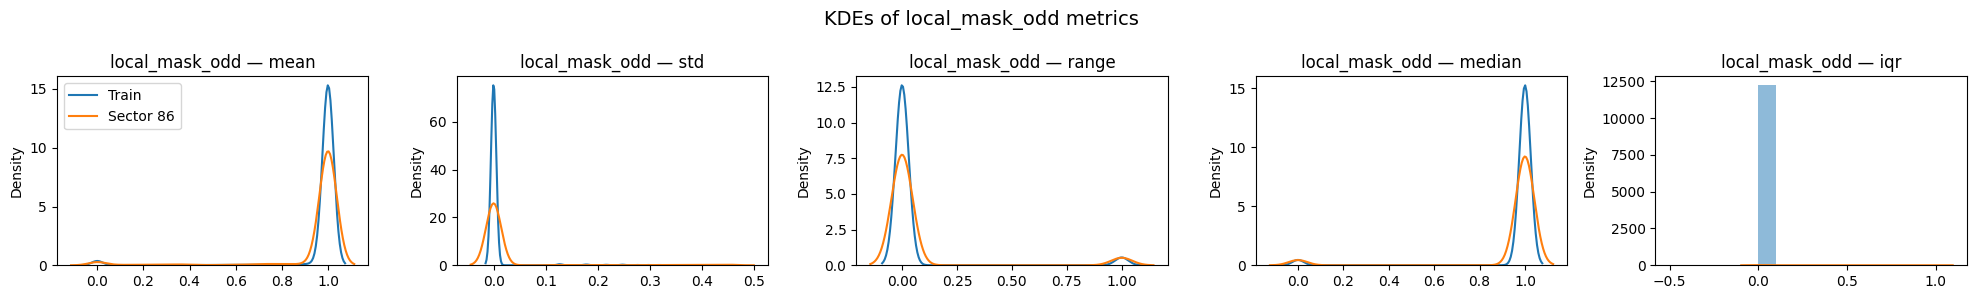

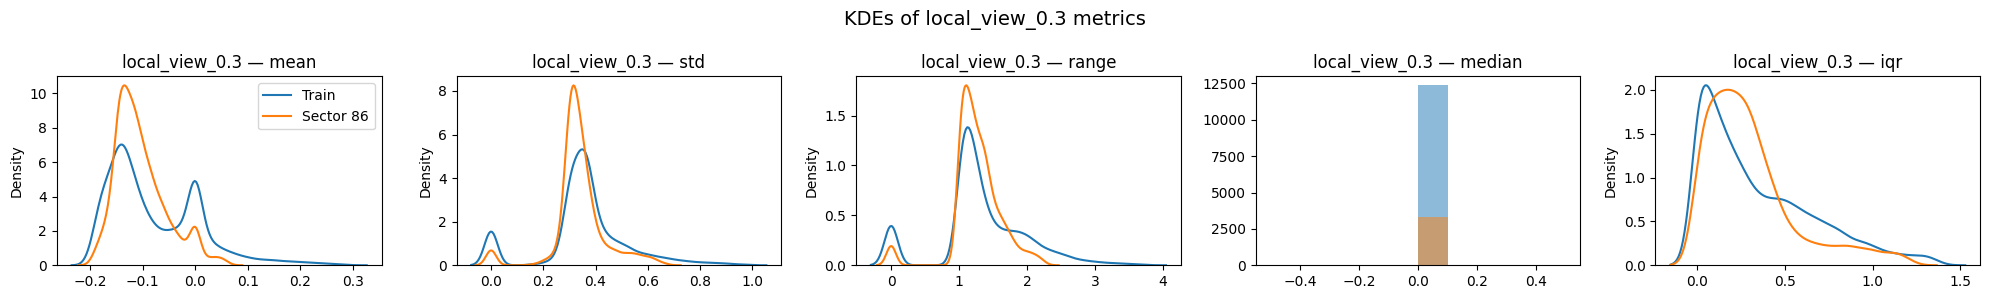

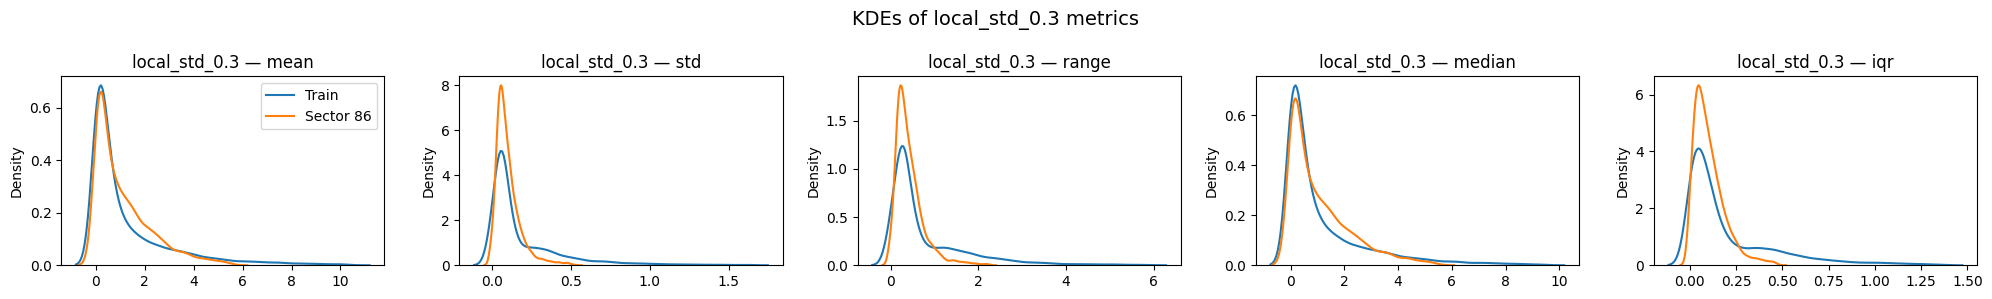

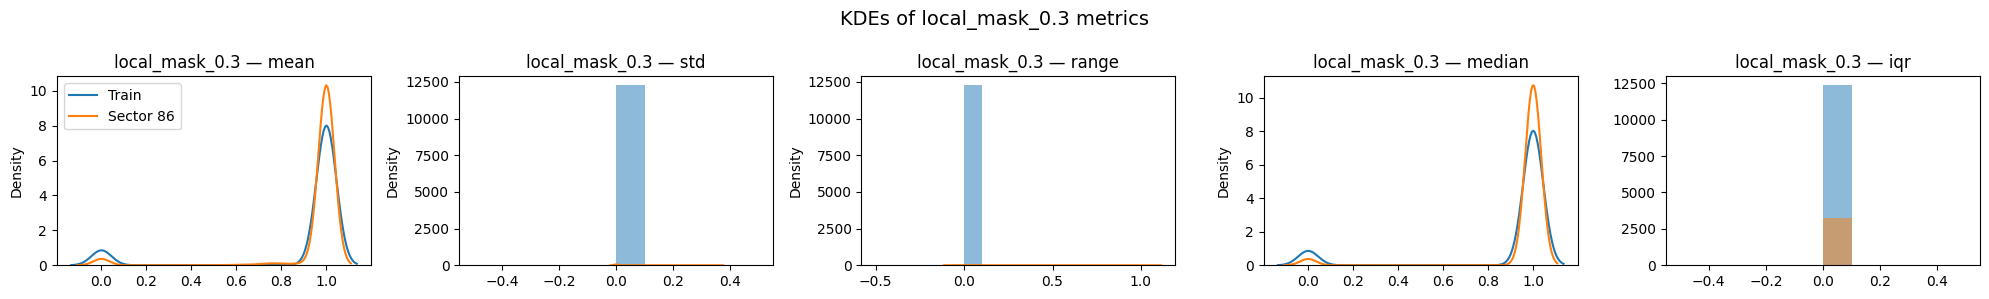

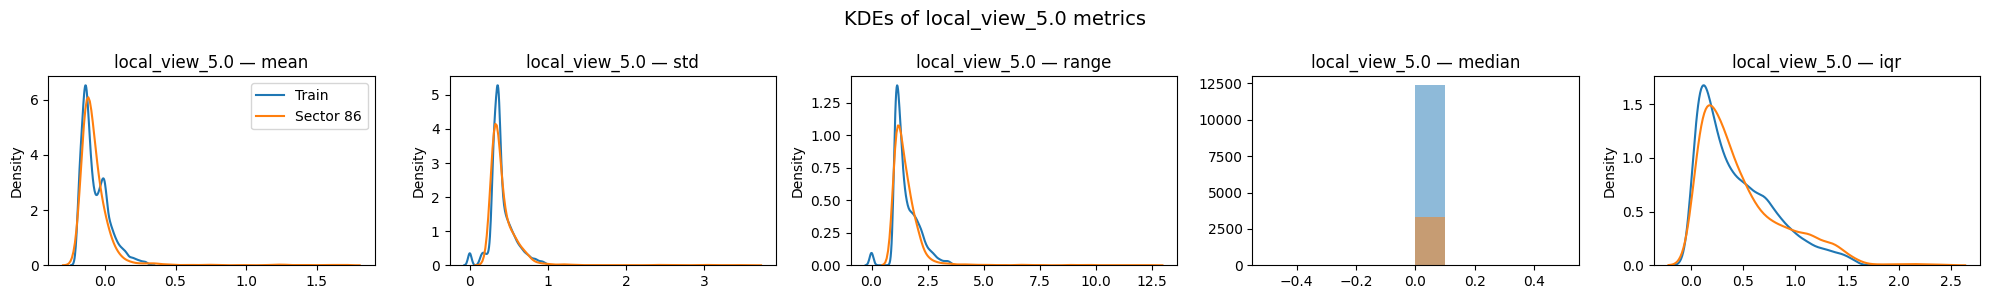

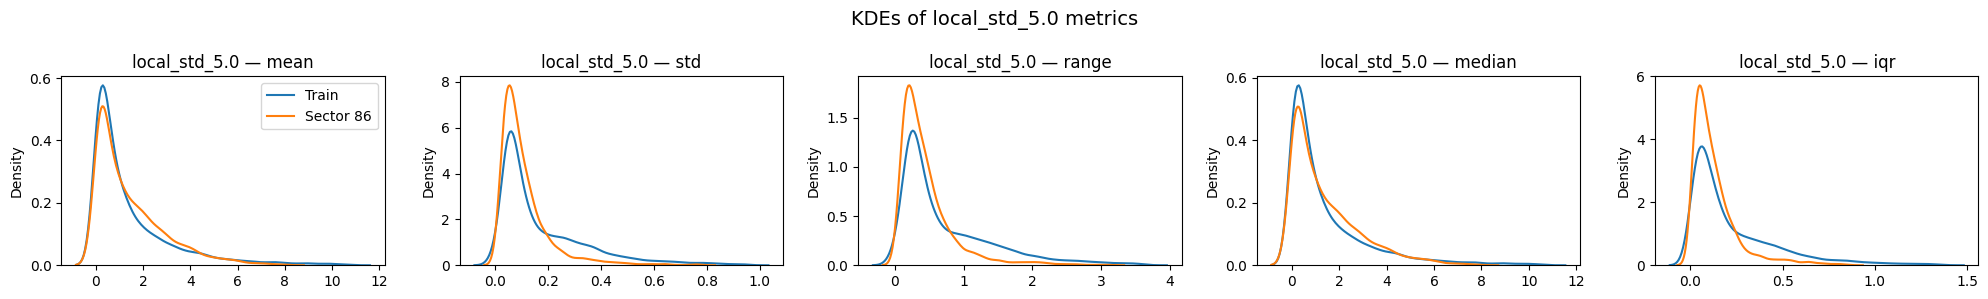

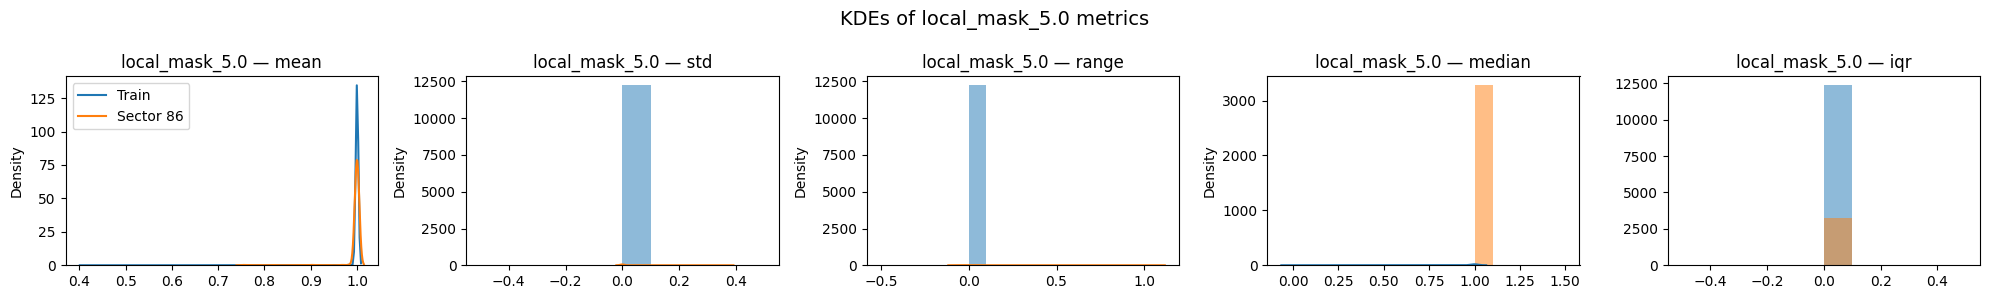

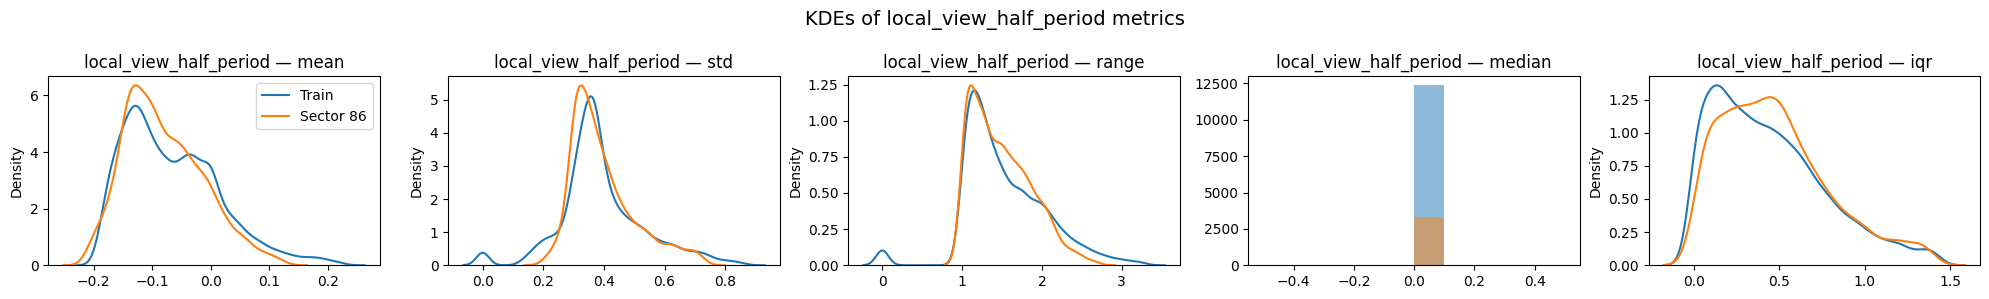

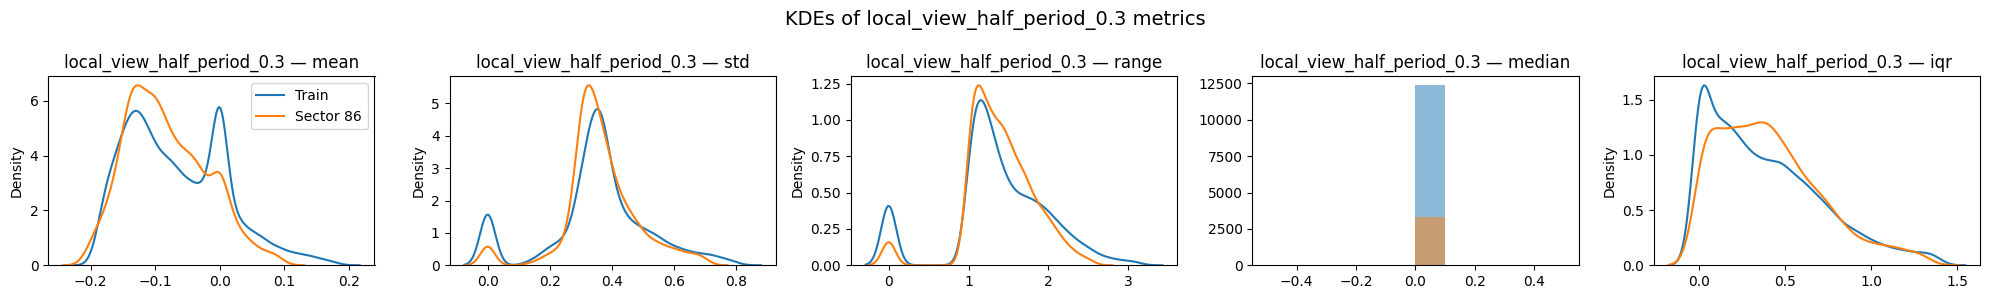

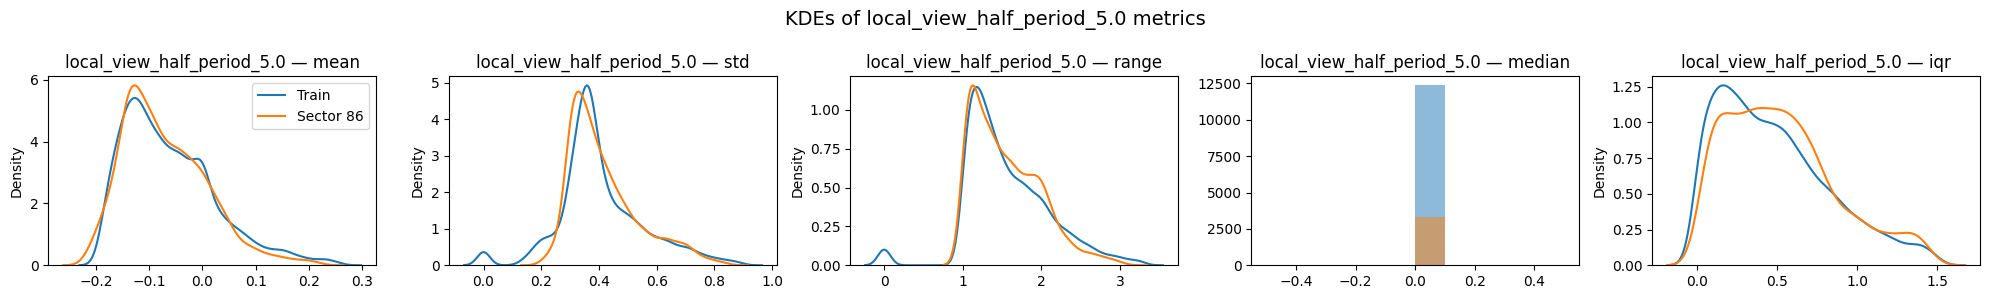

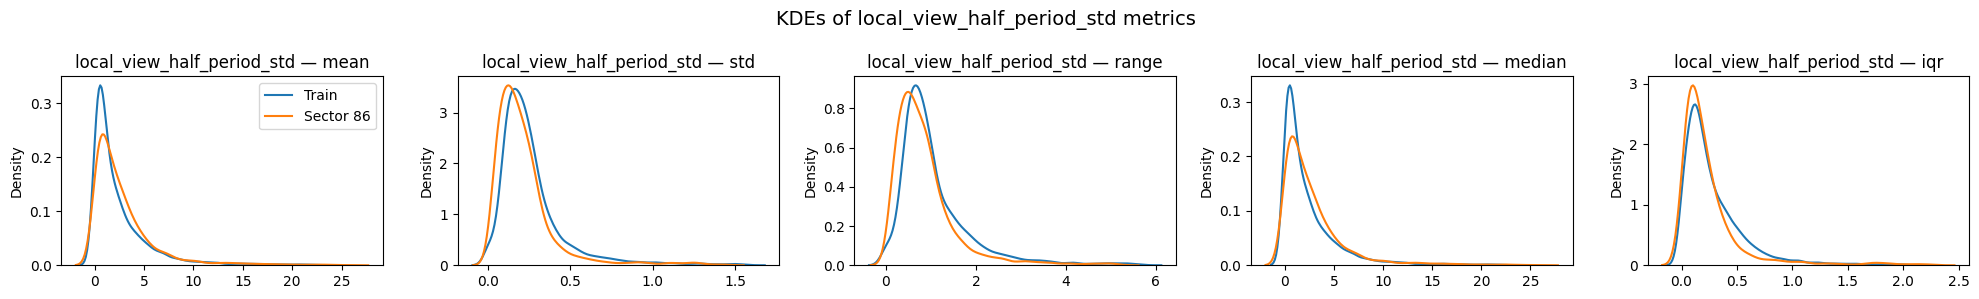

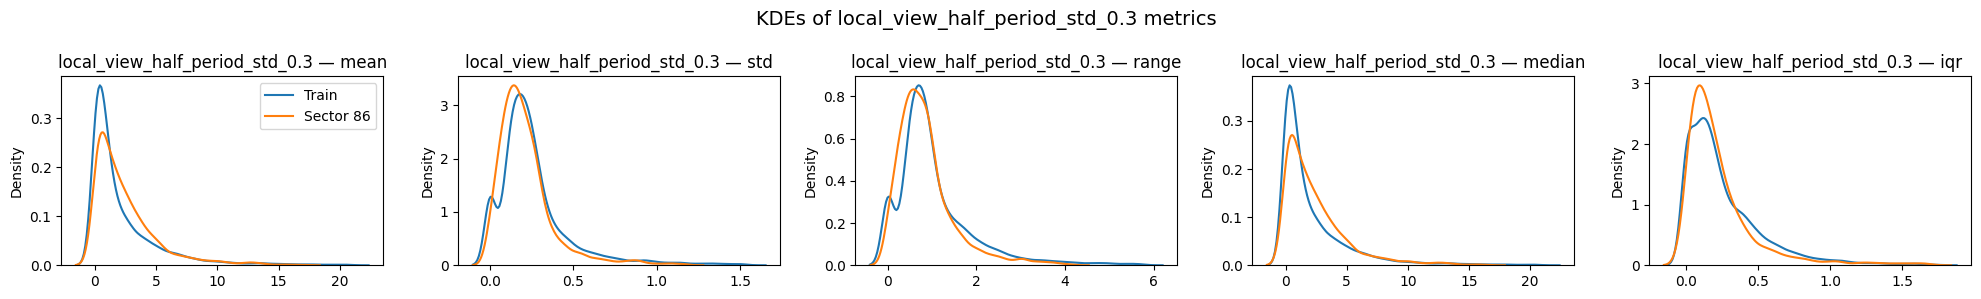

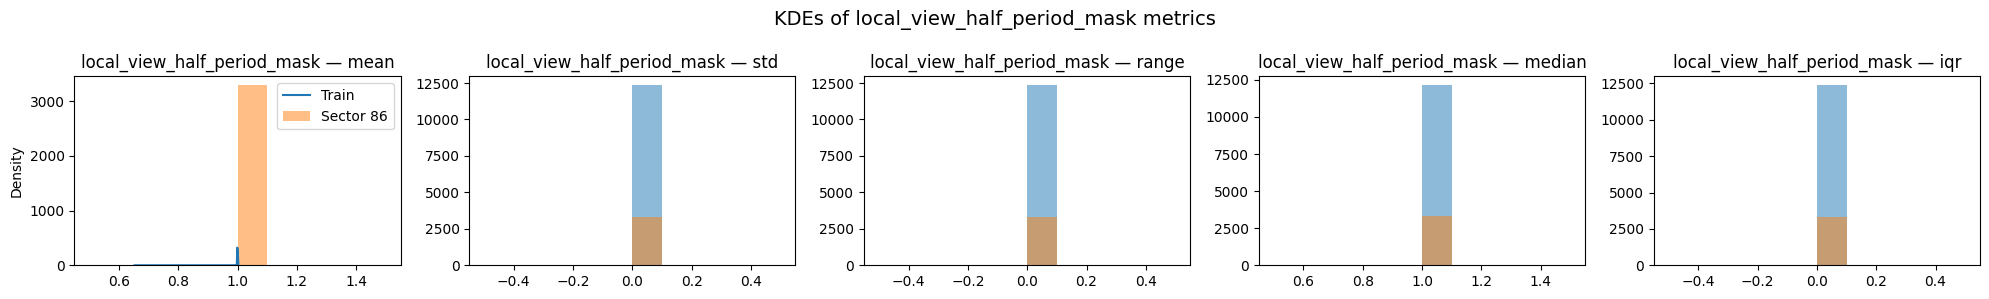

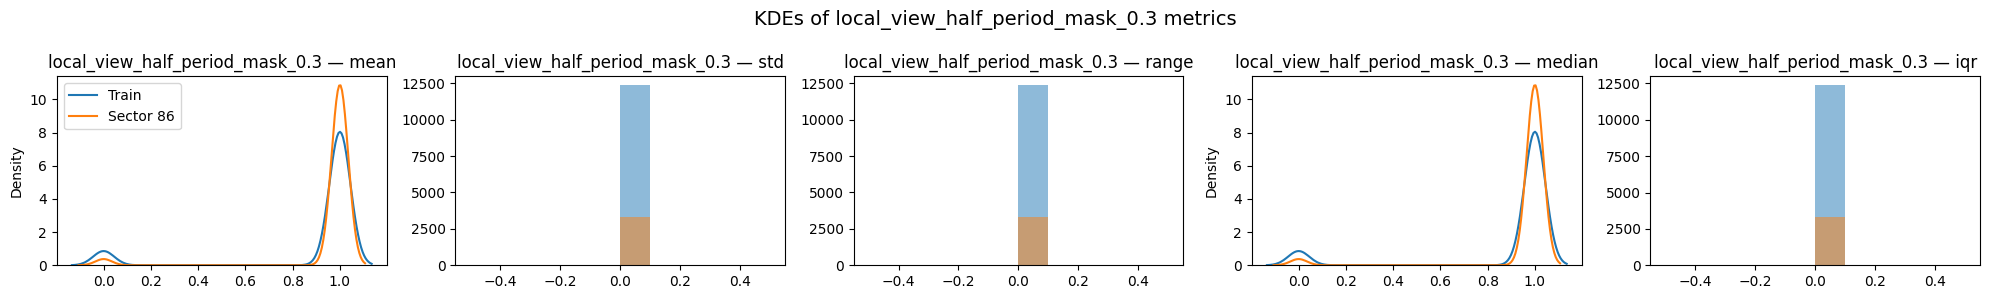

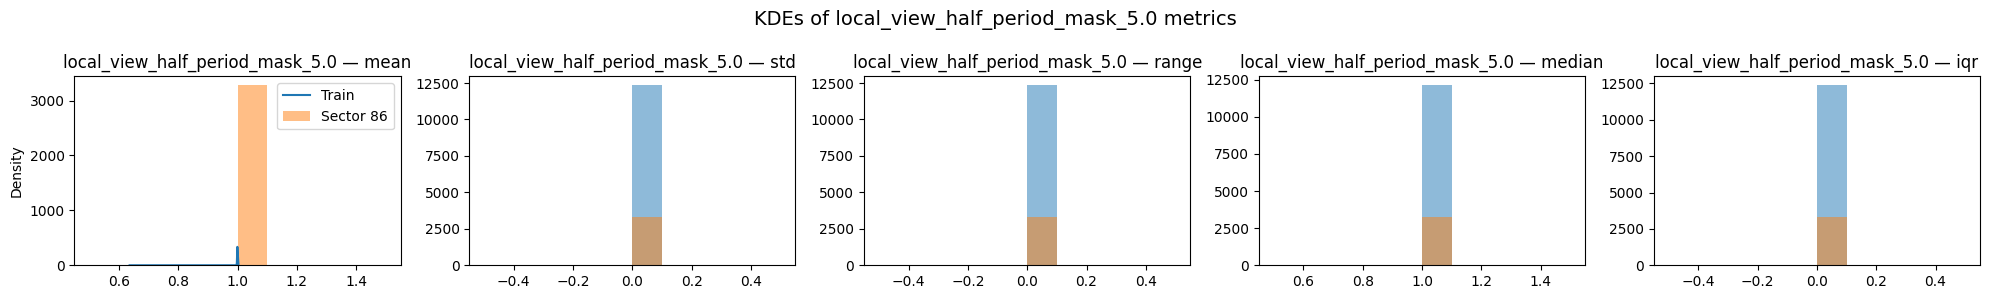

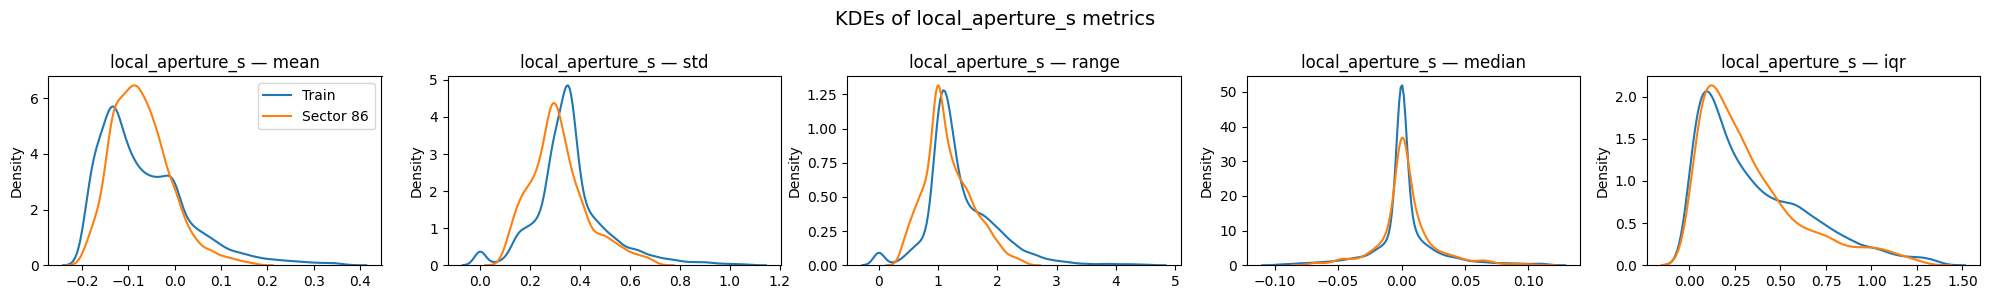

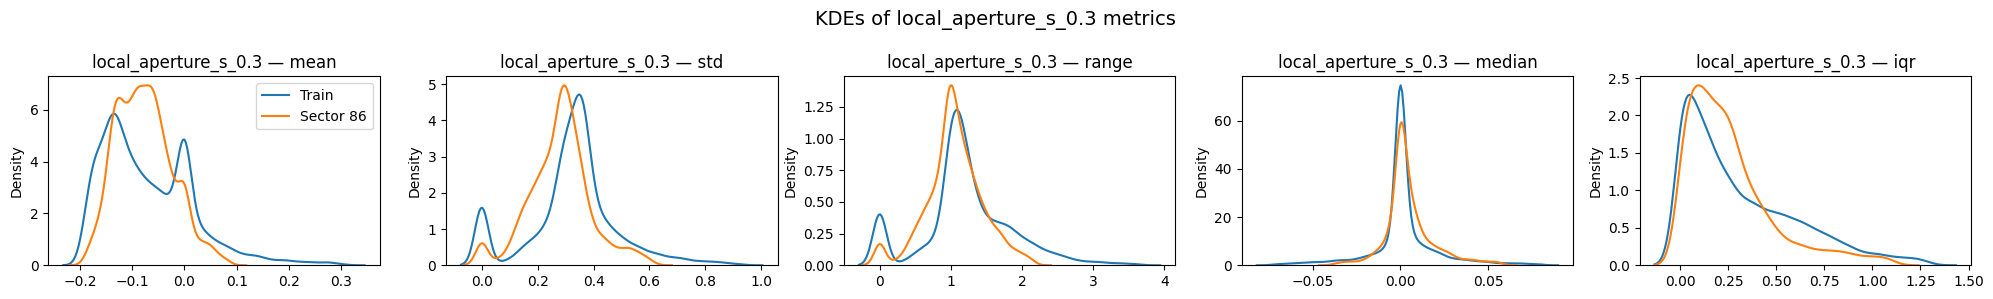

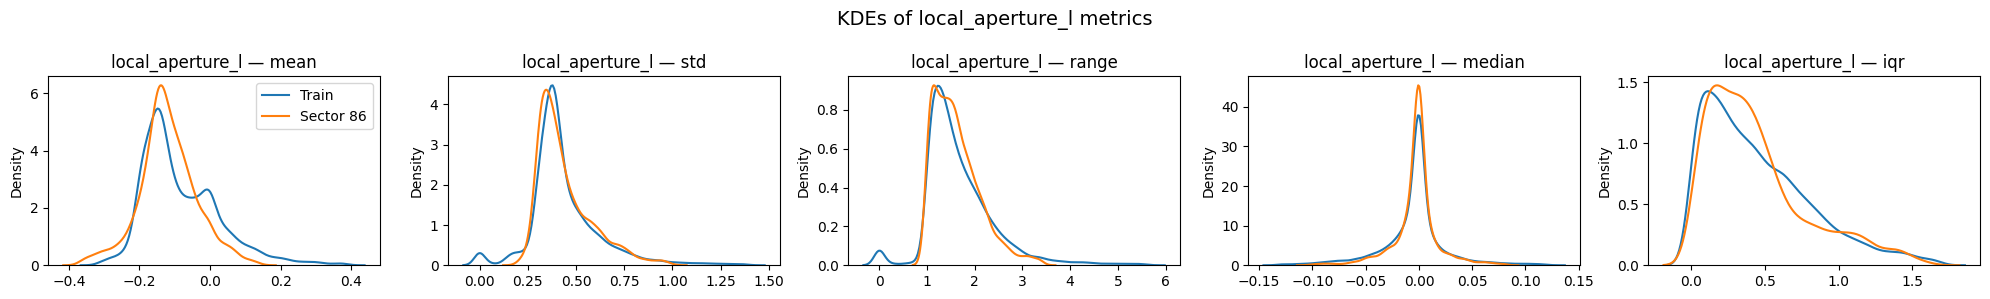

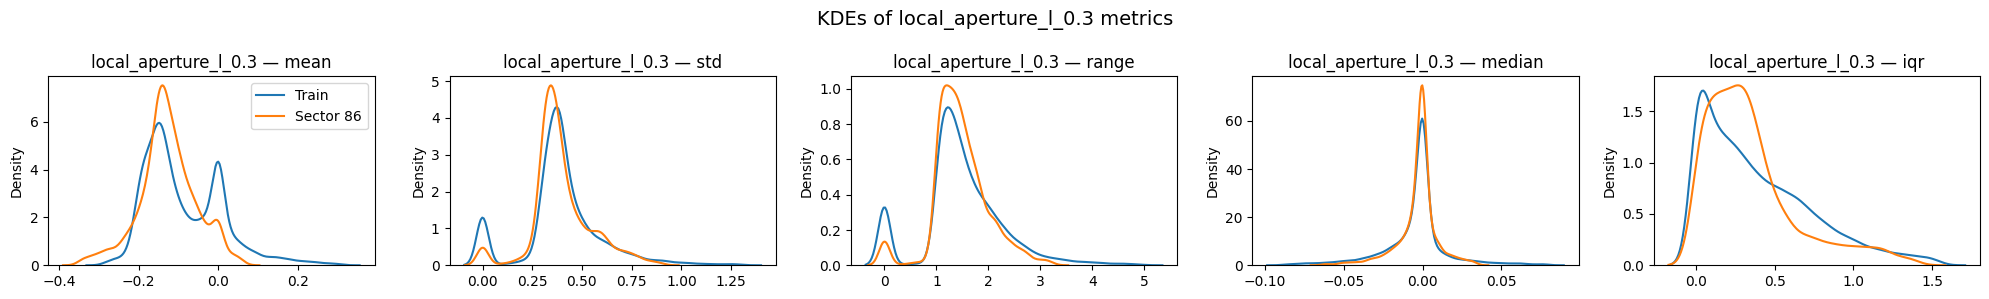

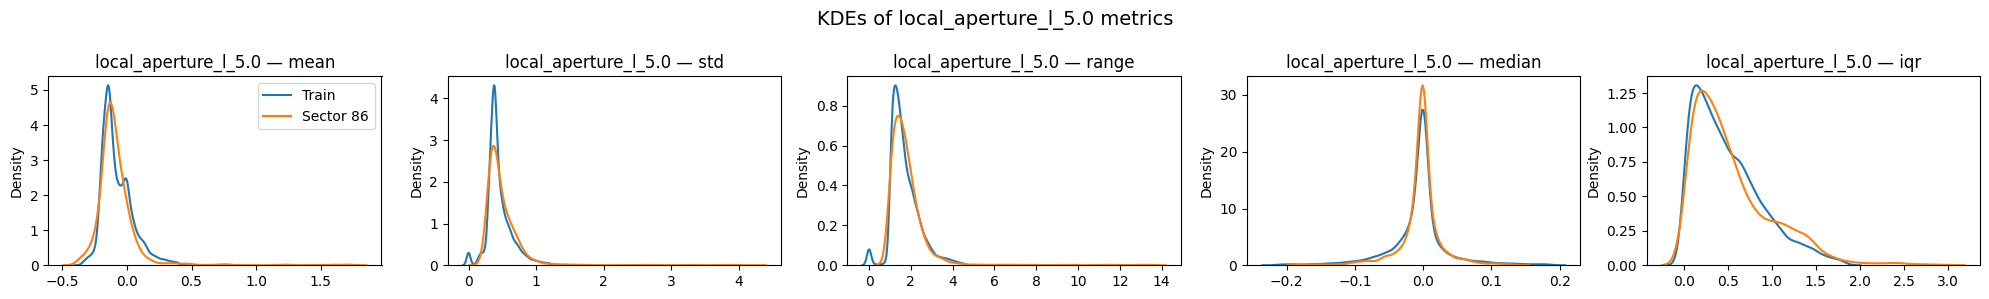

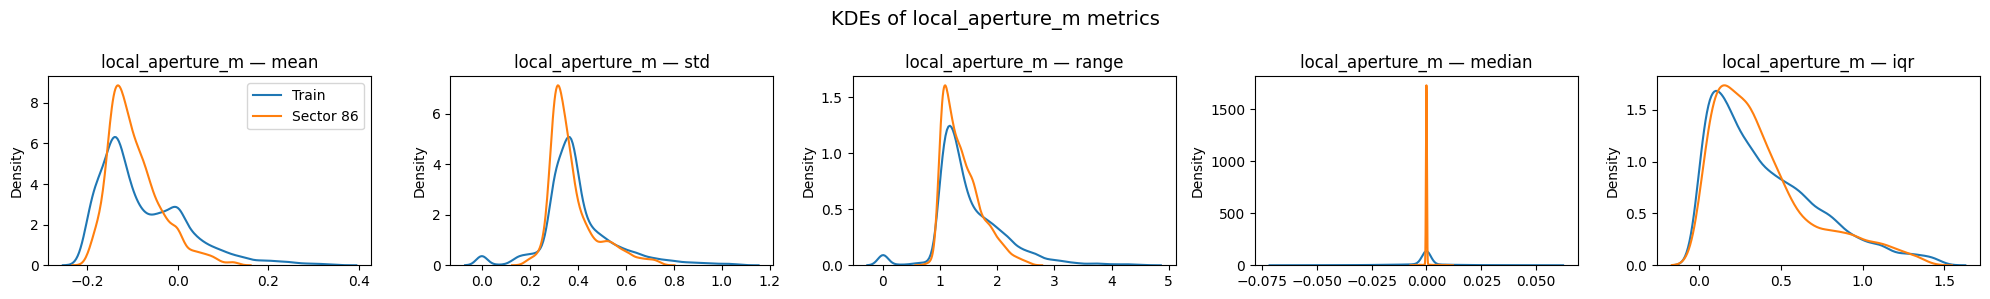

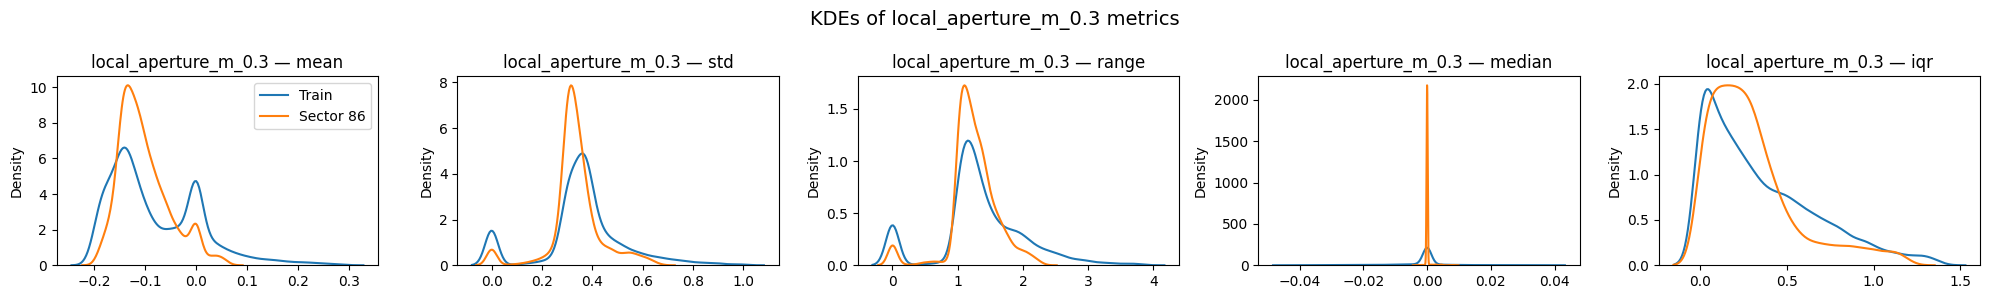

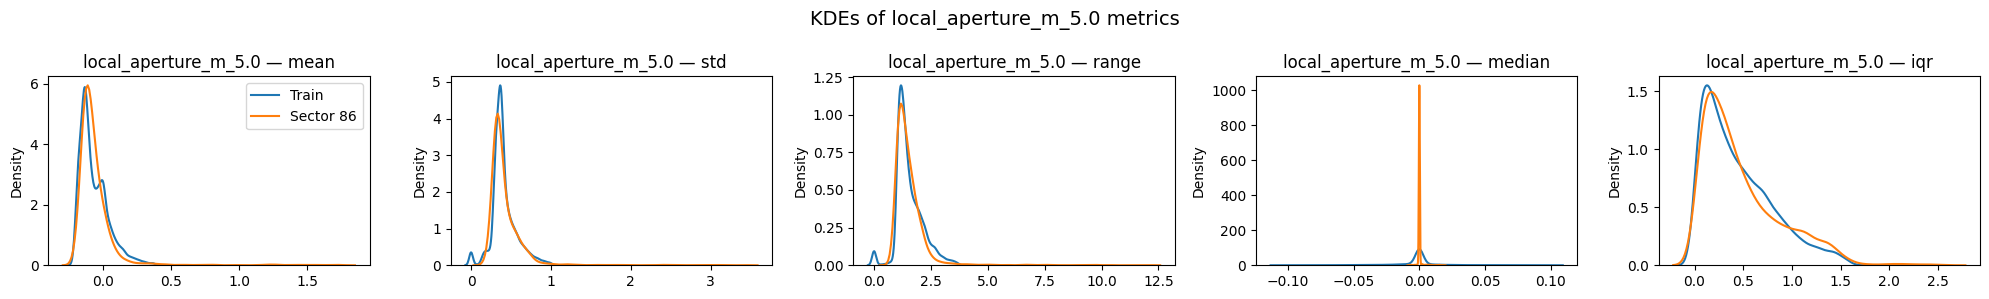

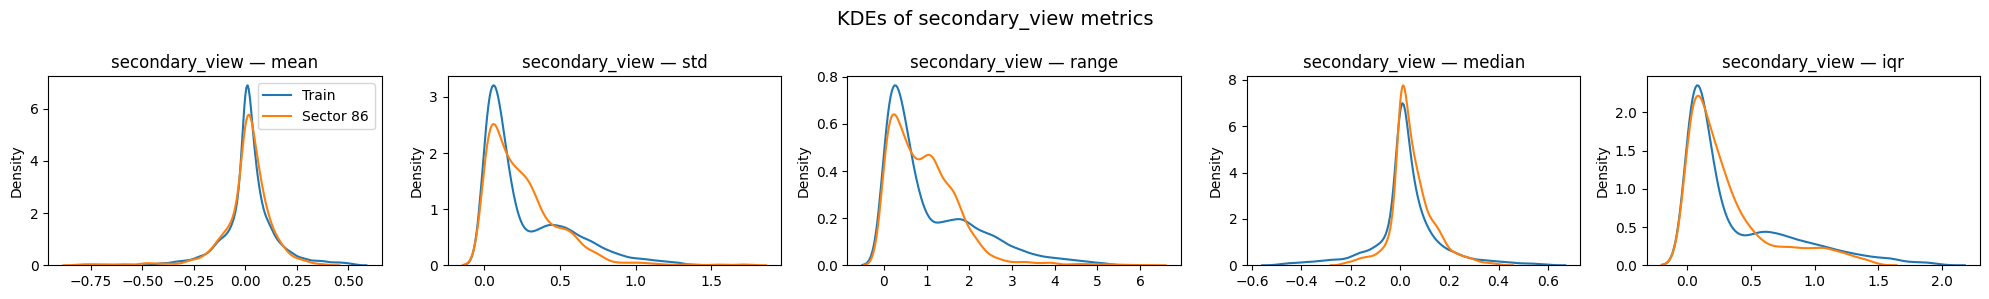

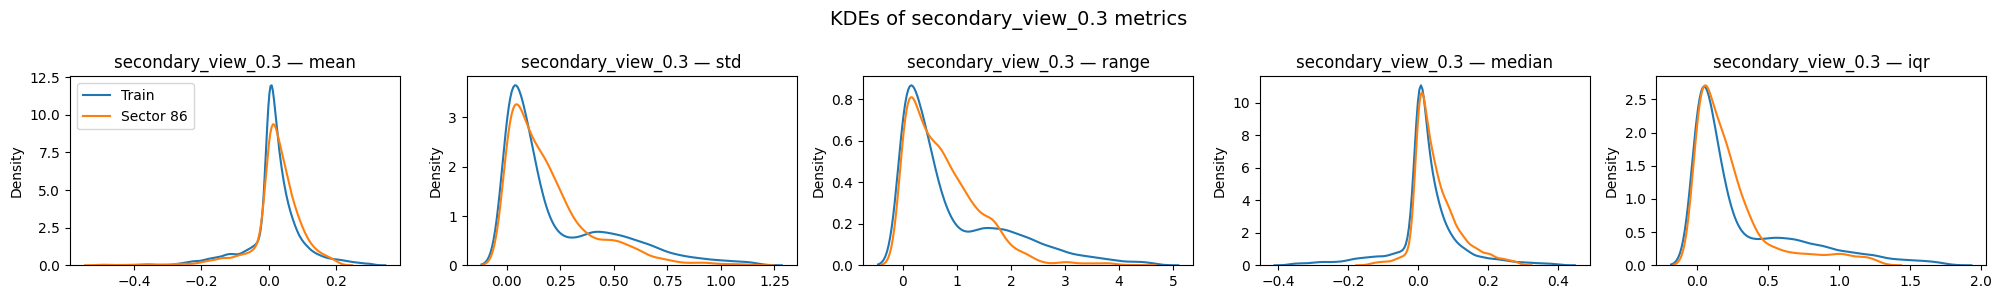

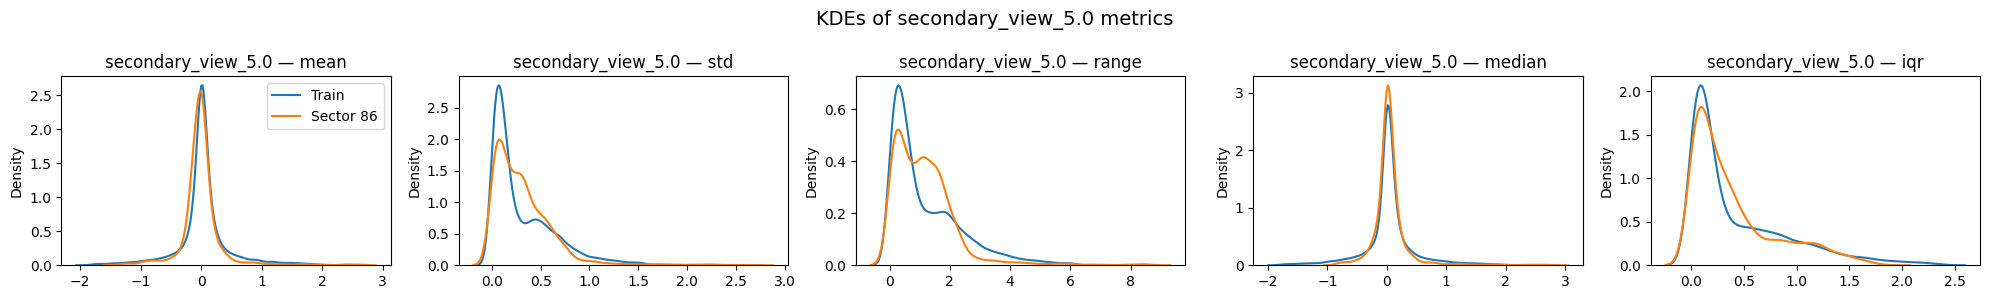

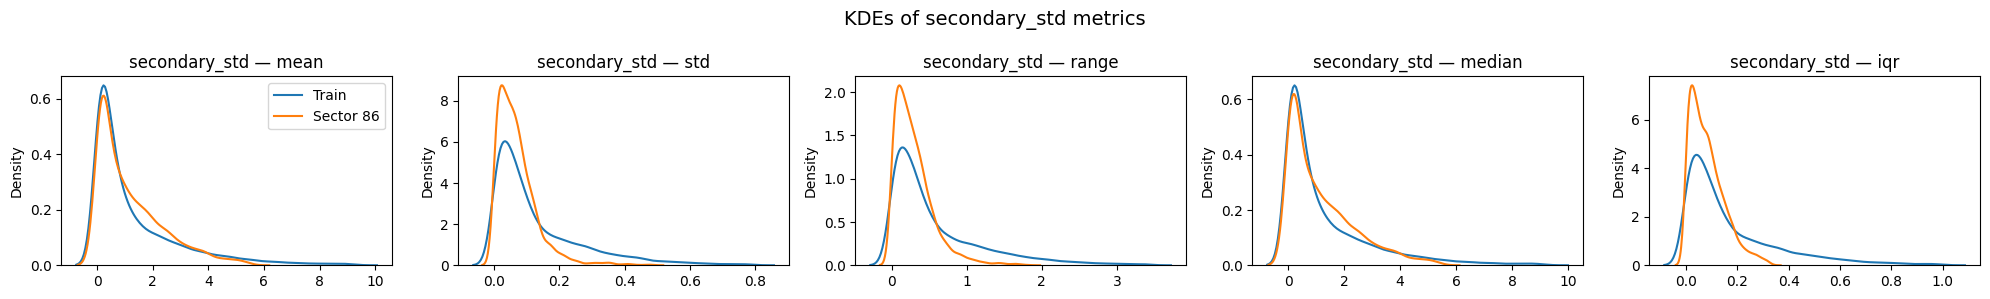

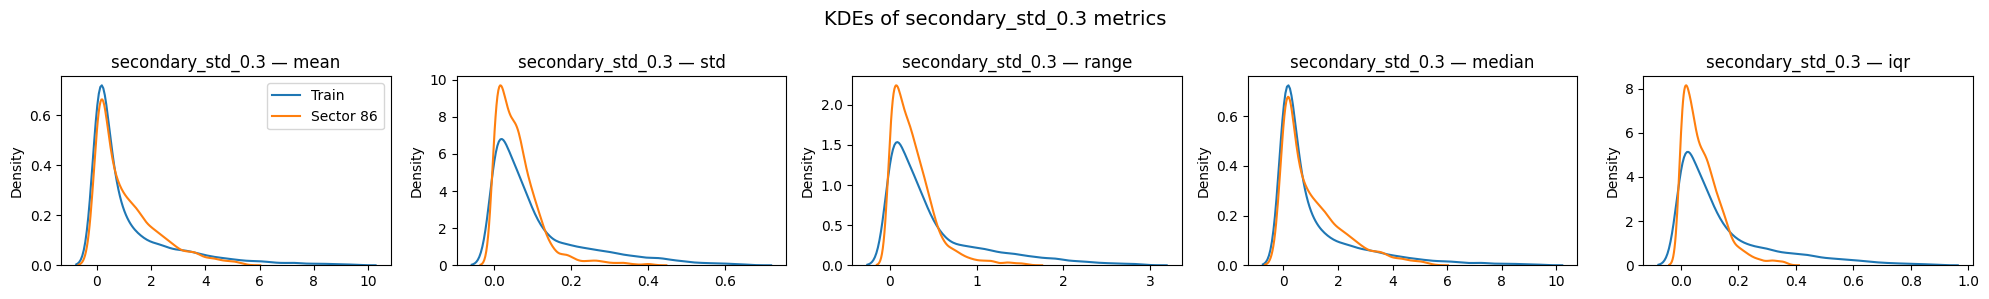

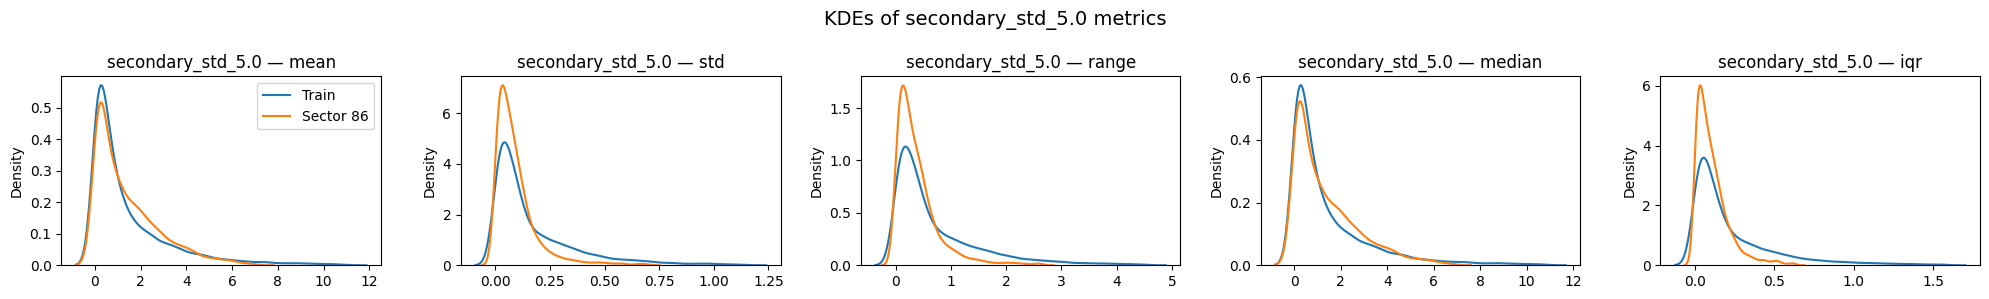

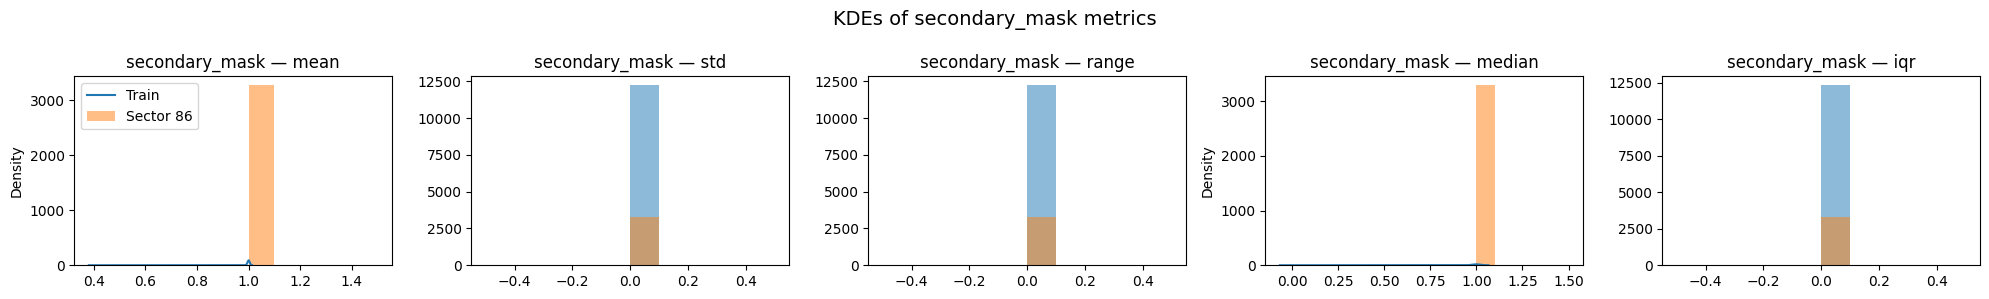

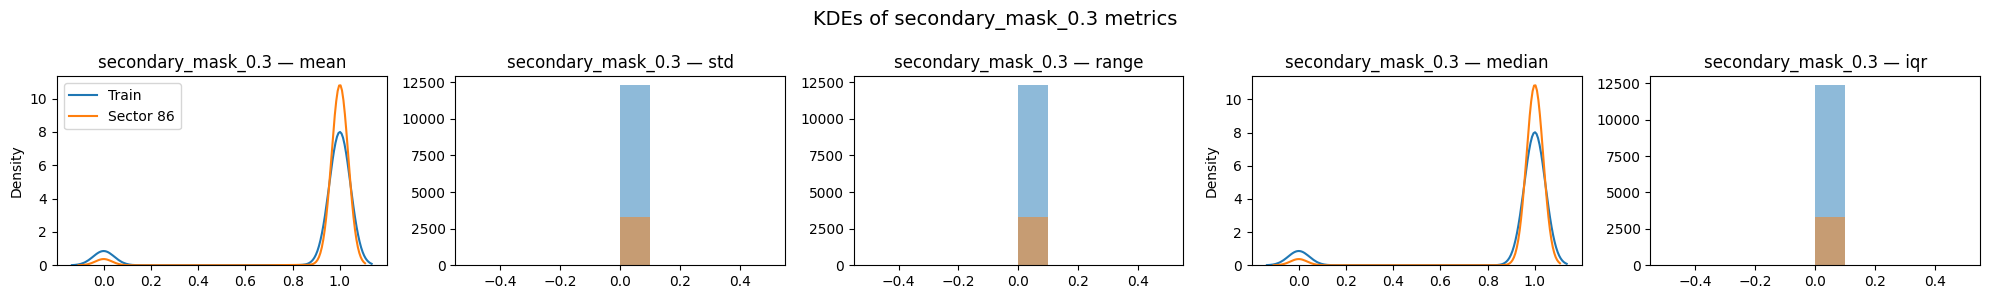

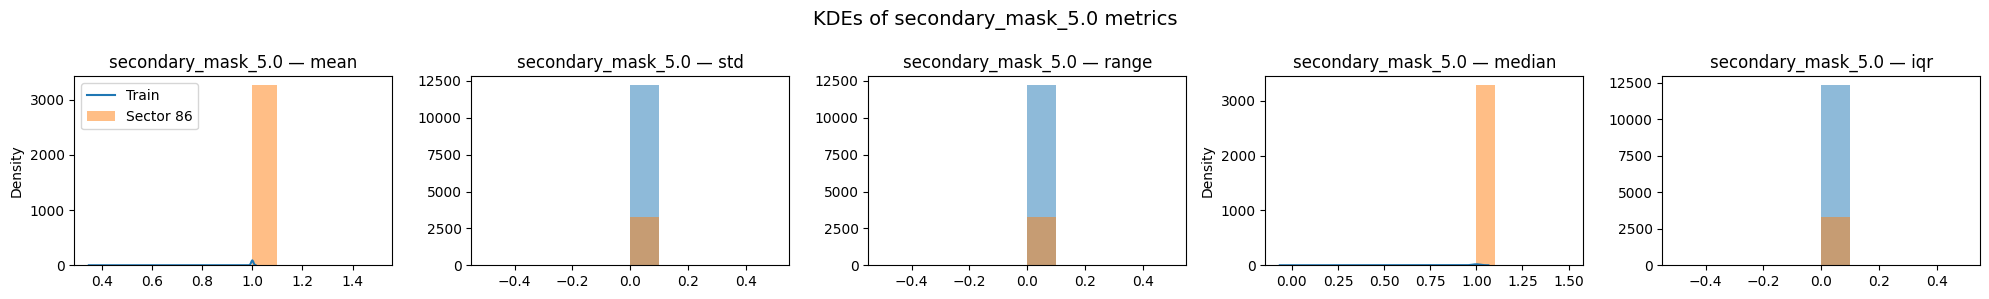

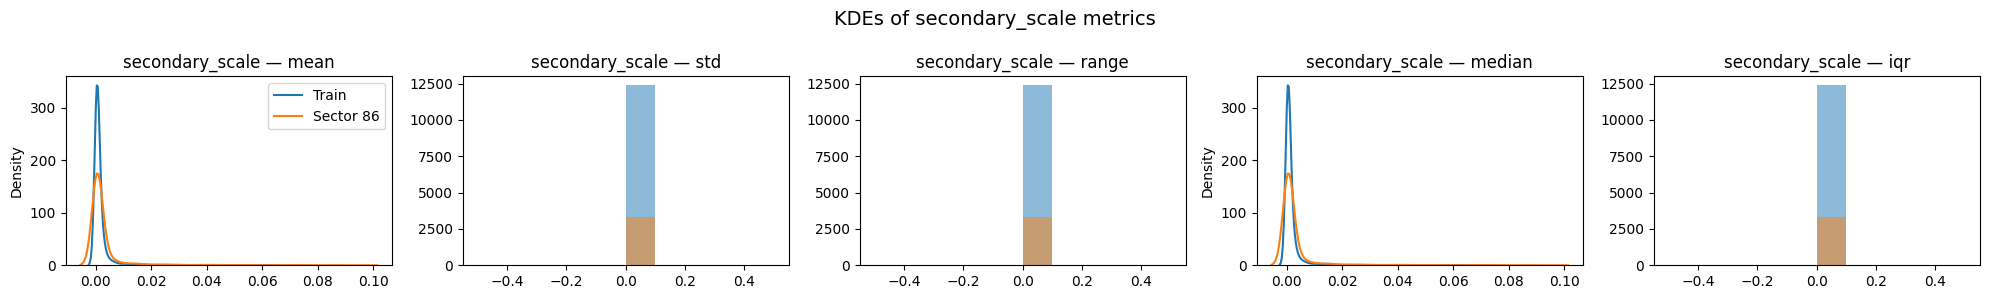

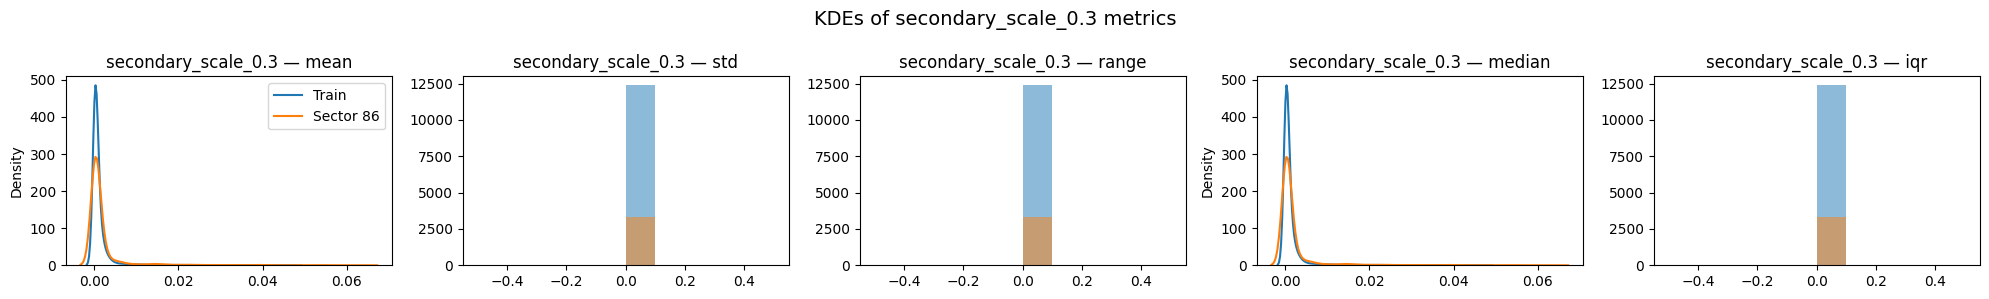

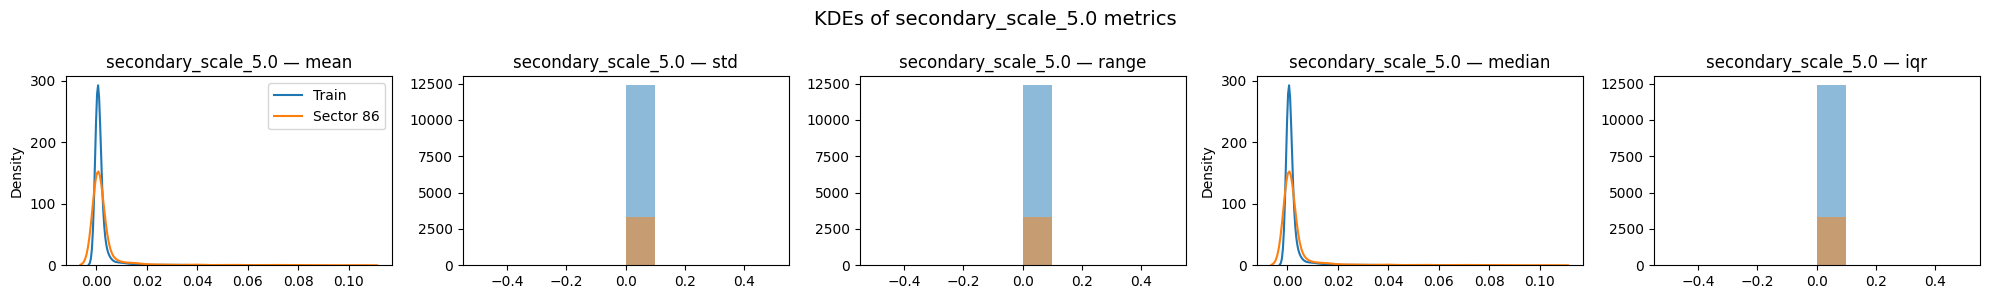

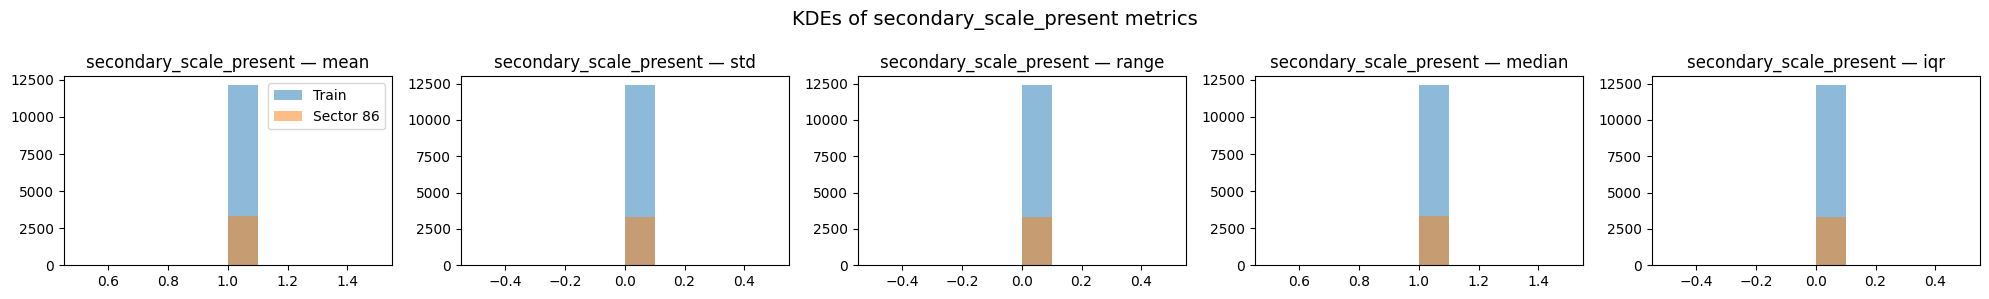

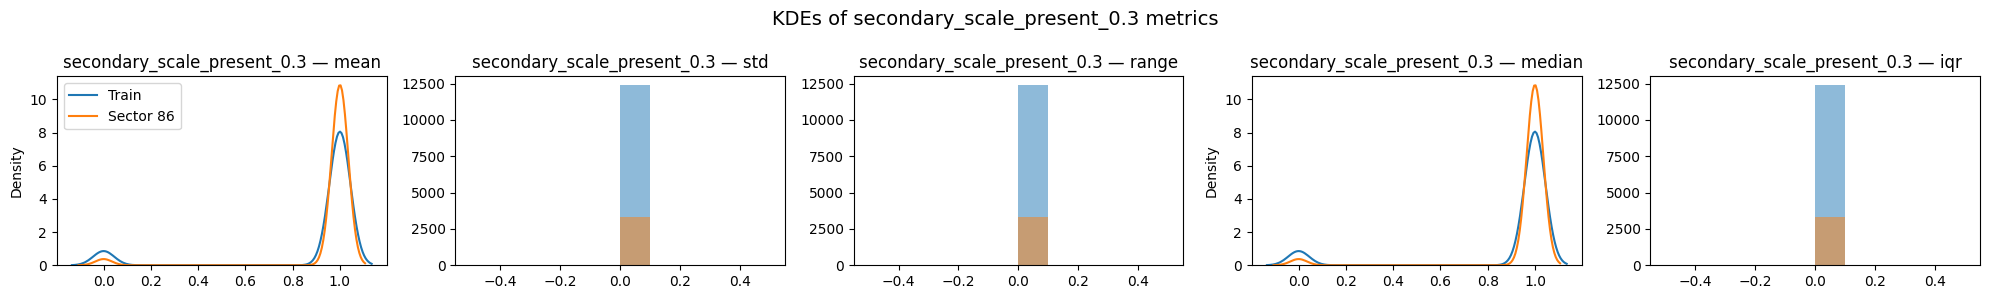

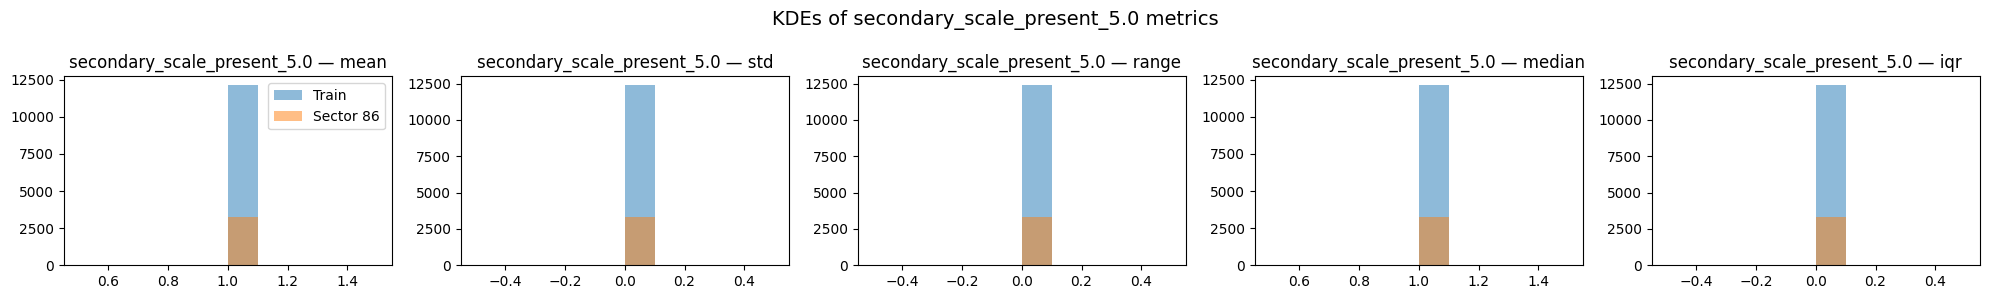

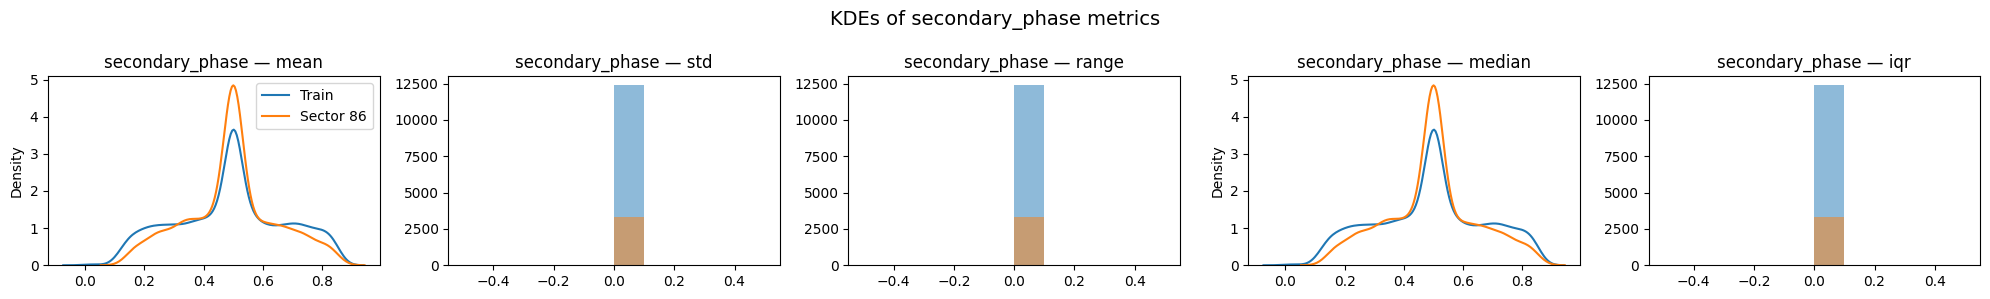

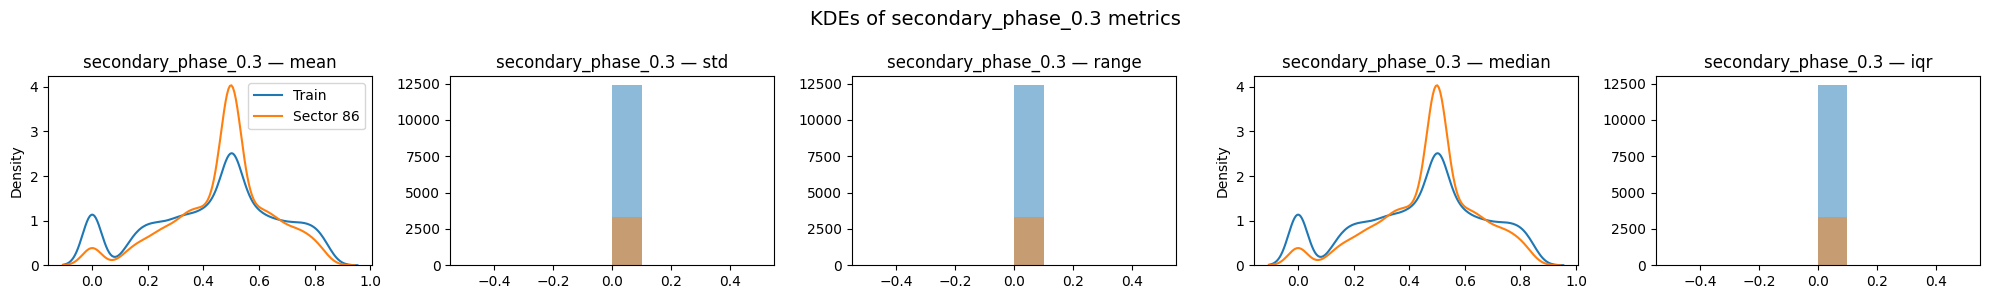

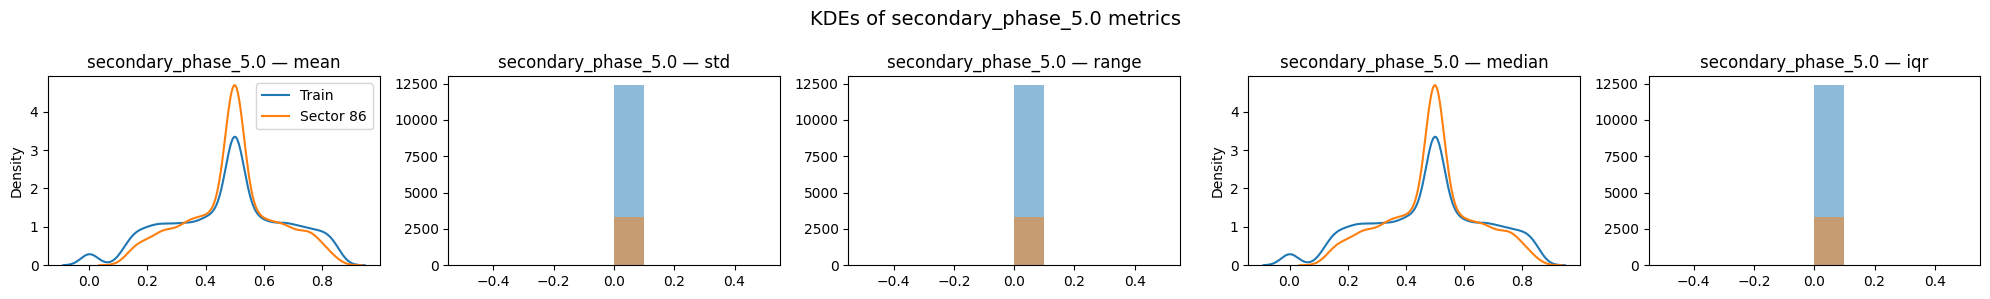

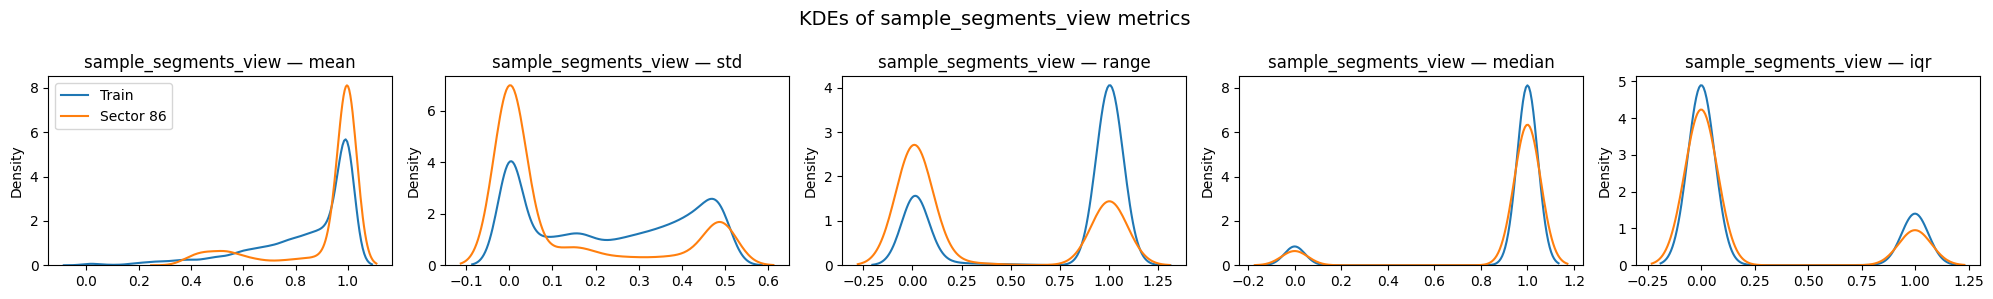

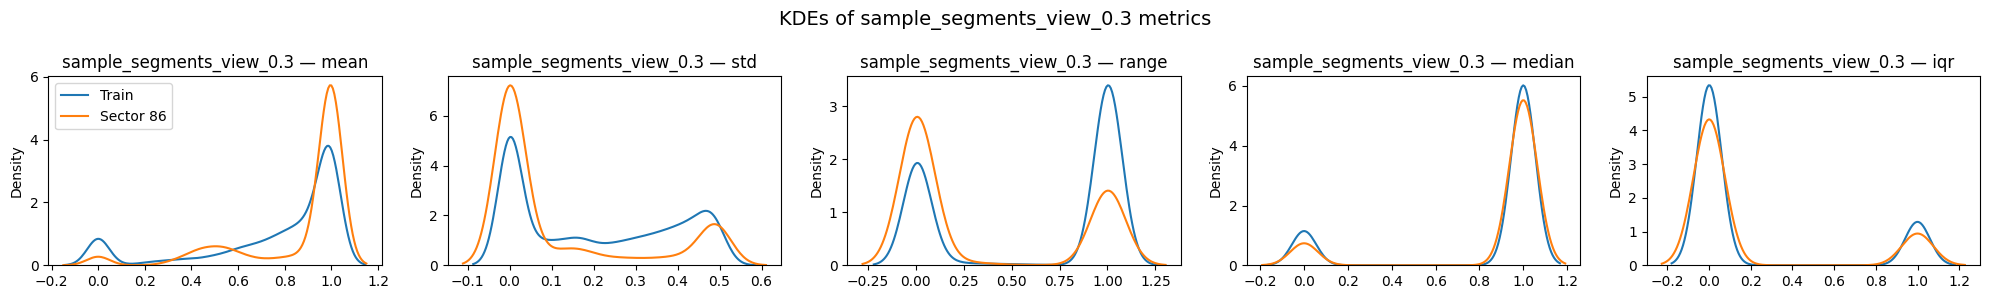

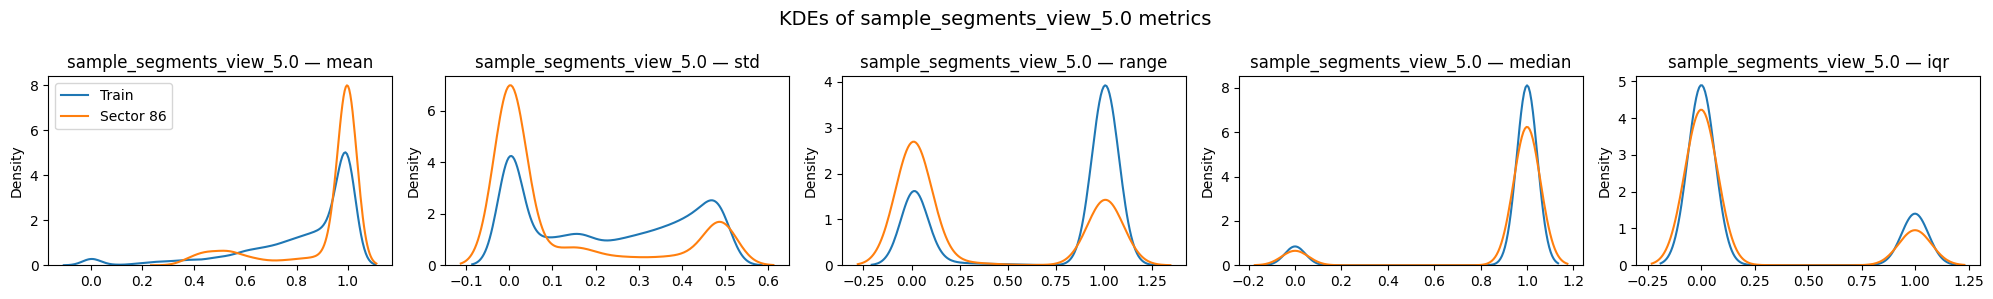

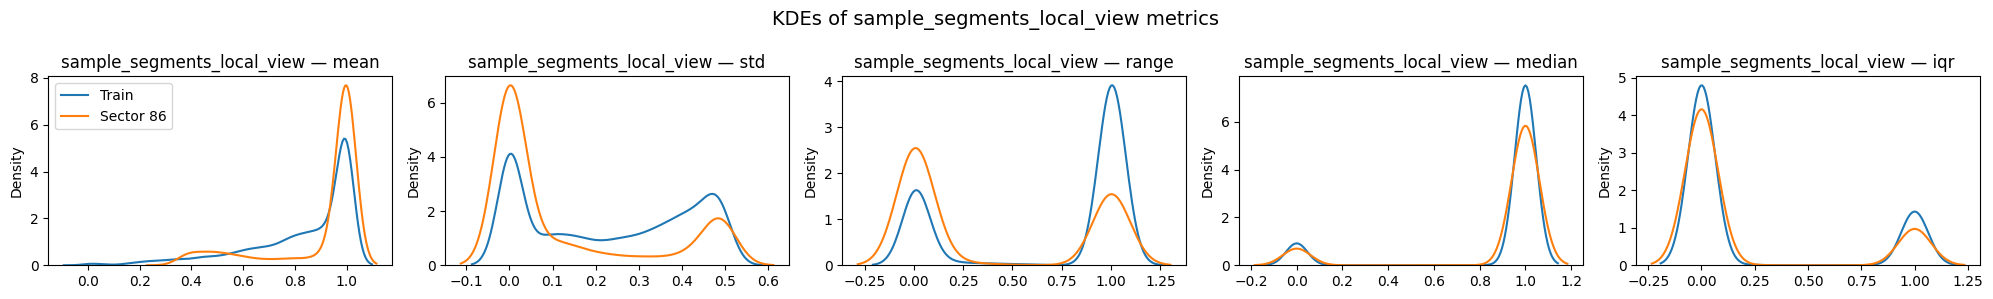

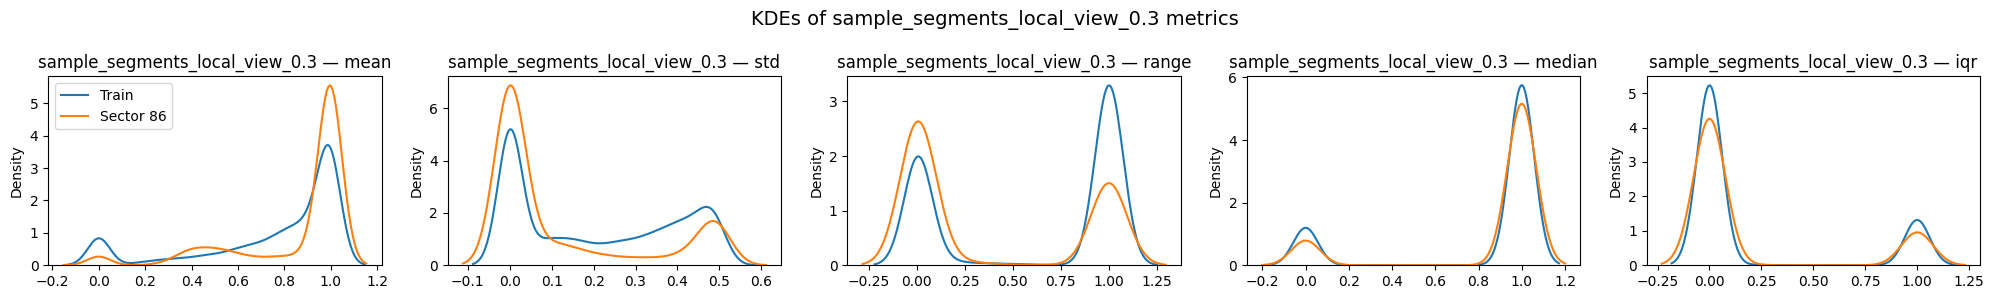

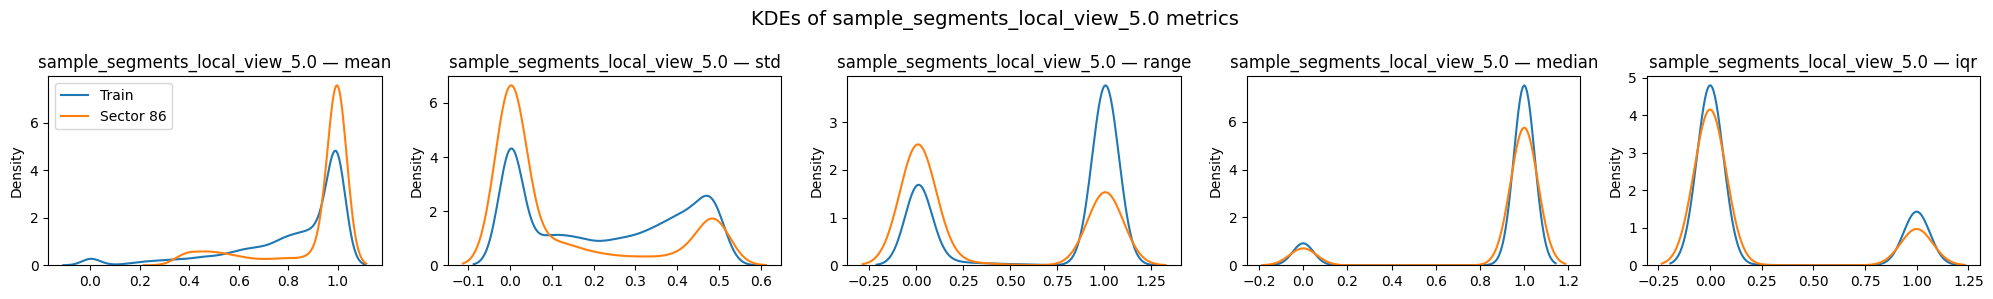

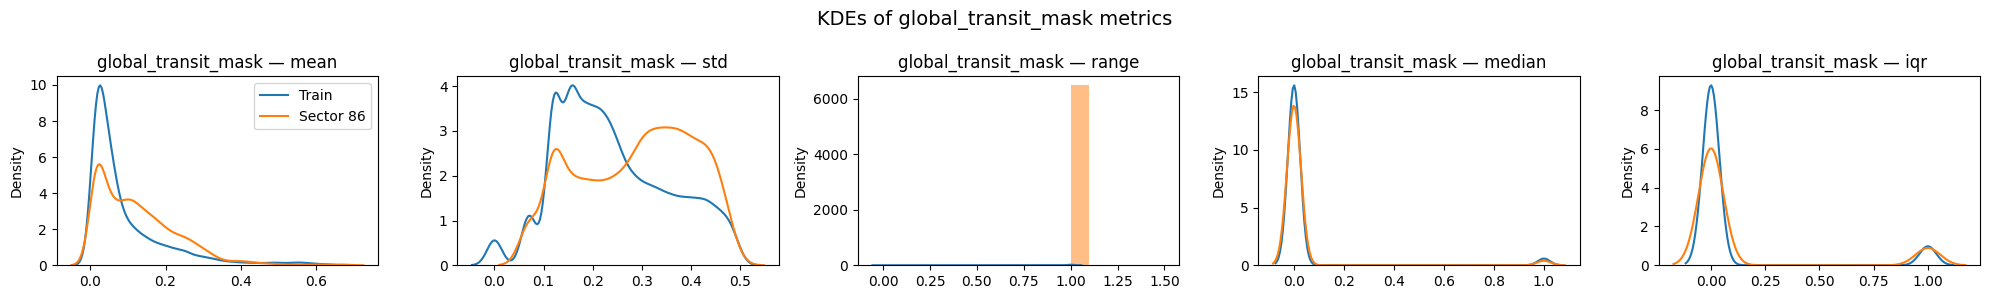

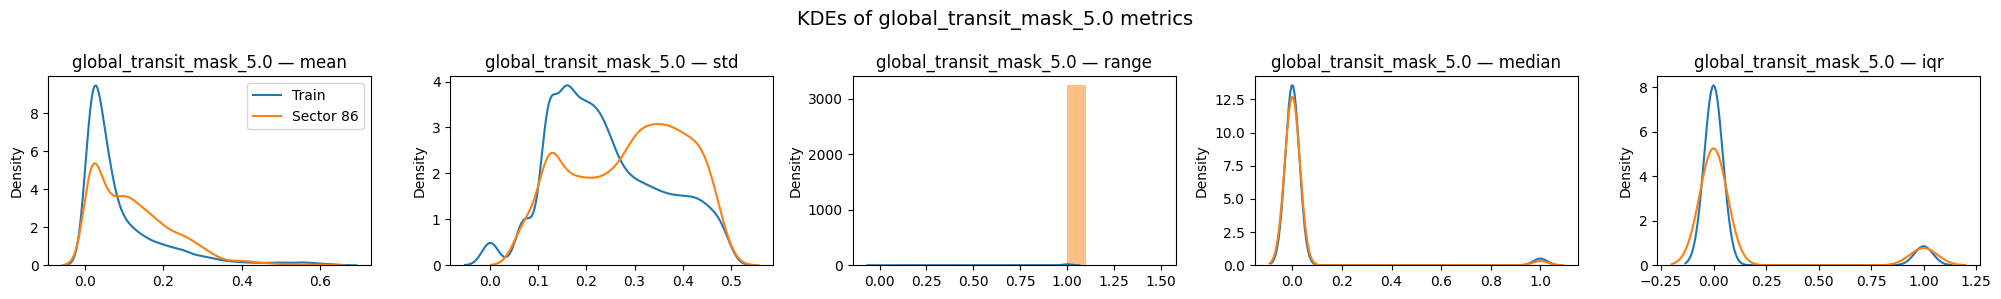

In [60]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

# reuse your existing file lists
files1 = get_tfrecord_files(PATH1)
files2 = get_tfrecord_files(PATH2)

# 1) list of all your time-series features
ts_features = [
#     # Global views:
    'global_view', 'global_std', 'global_mask', 'global_transit_mask',
    'global_view_0.3', 'global_std_0.3', 'global_mask_0.3',
    'global_view_5.0', 'global_std_5.0', 'global_mask_5.0',
    'global_view_half_period', 'global_view_half_period_0.3', 'global_view_half_period_5.0',
    'global_view_double_period',
    'global_view_double_period_mask',
    'global_view_double_period_mask_0.3',
    'global_view_double_period_mask_5.0',
    'global_view_double_period_std',
    'global_view_double_period_std_0.3',
    'global_view_double_period_std_5.0',
# ]
#     # Local views:
    'local_view', 'local_std', 'local_mask',
    'local_scale', 'local_scale_present',
    'local_view_even', 'local_std_even', 'local_mask_even',
    'local_view_odd', 'local_std_odd', 'local_mask_odd',
    'local_view_0.3', 'local_std_0.3', 'local_mask_0.3',
    'local_view_5.0', 'local_std_5.0', 'local_mask_5.0',
#     # Local half-period:
    'local_view_half_period', 'local_view_half_period_0.3', 'local_view_half_period_5.0',
    'local_view_half_period_std', 'local_view_half_period_std_0.3',
    'local_view_half_period_mask', 'local_view_half_period_mask_0.3', 'local_view_half_period_mask_5.0',
#     # Aperture:
    'local_aperture_s', 'local_aperture_s_0.3',
    'local_aperture_l', 'local_aperture_l_0.3', 'local_aperture_l_5.0',
    'local_aperture_m', 'local_aperture_m_0.3', 'local_aperture_m_5.0',
#     # Secondary:
    'secondary_view', 'secondary_view_0.3', 'secondary_view_5.0',
    'secondary_std', 'secondary_std_0.3', 'secondary_std_5.0',
    'secondary_mask', 'secondary_mask_0.3', 'secondary_mask_5.0',
    'secondary_scale', 'secondary_scale_0.3', 'secondary_scale_5.0',
    'secondary_scale_present', 'secondary_scale_present_0.3', 'secondary_scale_present_5.0',
    'secondary_phase', 'secondary_phase_0.3', 'secondary_phase_5.0',
#     # Sample segments:
    'sample_segments_view', 'sample_segments_view_0.3', 'sample_segments_view_5.0',
    'sample_segments_local_view', 'sample_segments_local_view_0.3', 'sample_segments_local_view_5.0',
#     # Misc:
    'global_transit_mask', 'global_transit_mask_5.0'
]

# ts_features = [
#     # Global views:
    # 'global_view', 'global_std', 'global_mask', 'global_transit_mask']


# 2) metrics to compute
metrics = ['mean', 'std', 'range', 'median', 'iqr']

def extract_ts_metrics(tfrecord_files, feature_names, max_examples=15000):
    # initialize storage
    out = {feat: {m: [] for m in metrics} for feat in feature_names}
    ds = tf.data.TFRecordDataset(tfrecord_files).take(max_examples)
    for raw in ds:
        ex = tf.train.Example()
        ex.ParseFromString(raw.numpy())
        for feat in feature_names:
            f = ex.features.feature.get(feat)
            if f is None or not f.float_list.value:
                continue
            arr = np.array(f.float_list.value, dtype=float)
            # compute metrics
            mn   = arr.mean()
            sd   = arr.std()
            rg   = arr.max() - arr.min()
            md   = np.median(arr)
            iqr  = np.percentile(arr, 75) - np.percentile(arr, 25)
            out[feat]['mean'].append(mn)
            out[feat]['std'].append(sd)
            out[feat]['range'].append(rg)
            out[feat]['median'].append(md)
            out[feat]['iqr'].append(iqr)
    # convert to arrays
    for feat in feature_names:
        for m in metrics:
            out[feat][m] = np.array(out[feat][m])
    return out

# extract for both splits
ts1 = extract_ts_metrics(files1, ts_features)
ts2 = extract_ts_metrics(files2, ts_features)

# 3) plotting
for feat in ts_features:
    fig, axes = plt.subplots(1, len(metrics), figsize=(len(metrics)*4, 3))
    for i, m in enumerate(metrics):
        ax = axes[i]
        a1 = ts1[feat][m]
        a2 = ts2[feat][m]
        # drop top 2% outliers for clarity
        thr1 = np.percentile(a1, 98)
        thr2 = np.percentile(a2, 98)
        # sns.kdeplot(a1[a1 <= thr1], ax=ax, label='Train', common_norm=False)
        # sns.kdeplot(a2[a2 <= thr2], ax=ax, label='Sector 86', common_norm=False)
        # ax.set_title(f"{feat} — {m}")


        b1 = a1[a1 <= thr1]
        b2 = a2[a2 <= thr2]

        x1 = b1[b1 >= np.percentile(b1, 2)]
        x2 = b2[b2 >= np.percentile(b2, 2)]

        # TRAIN SET
        if np.isclose(x1.std(), 0):  # all values the same
            ax.hist(x1, alpha=0.5, label='Train')
        else:
            sns.kdeplot(x1, ax=ax, label='Train', common_norm=False)

        # SECTOR 86
        if np.isclose(x2.std(), 0):
            ax.hist(x2, alpha=0.5, label='Sector 86')
        else:
            sns.kdeplot(x2, ax=ax, label='Sector 86', common_norm=False)

        ax.set_title(f"{feat} — {m}")


        if i == 0:
            ax.legend(loc='best')
    fig.suptitle(f"KDEs of {feat} metrics", fontsize=14)
    fig.tight_layout()
    plt.show()
